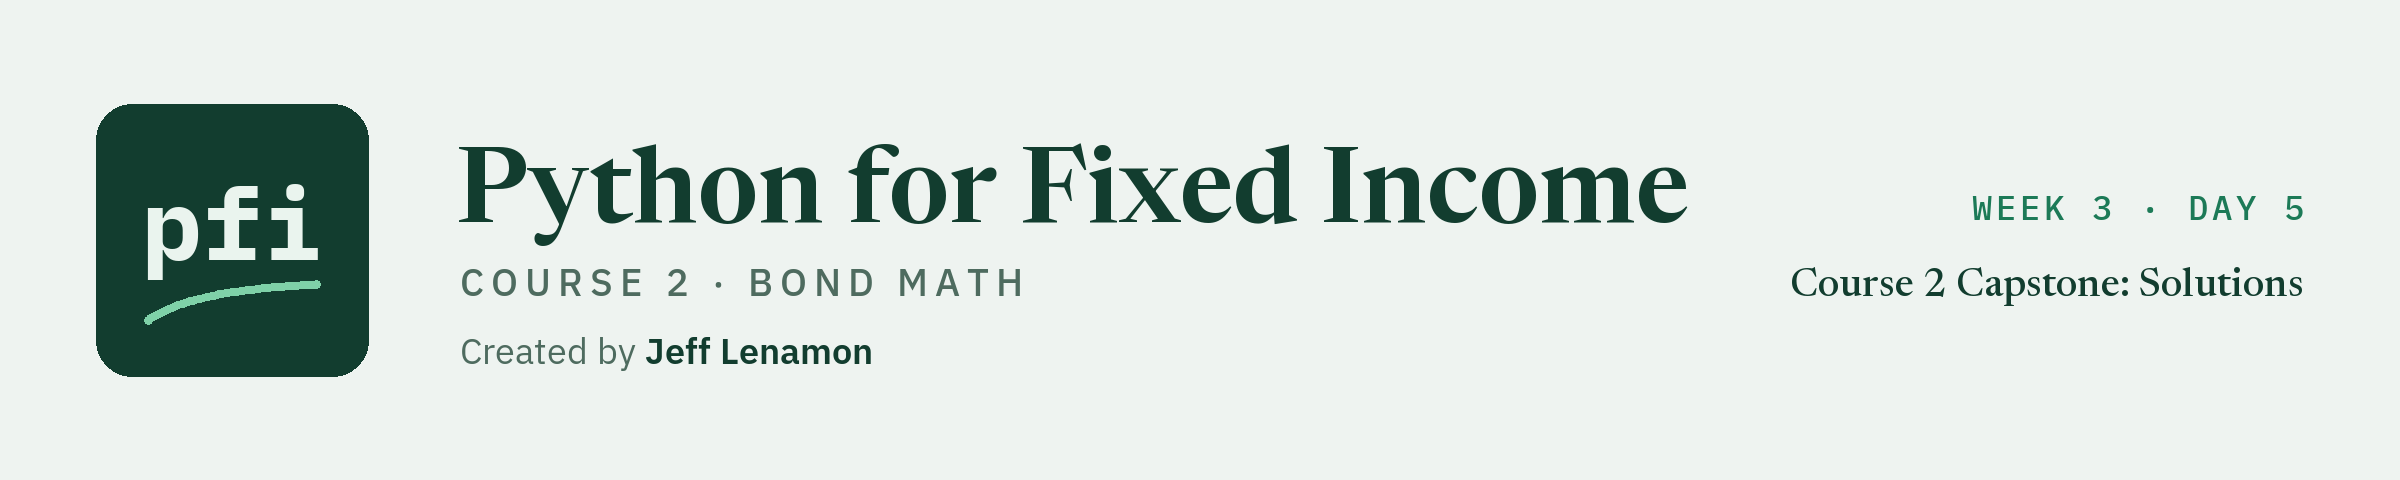

# Course 2 Capstone: Solutions

Week 3, Day 5. The worked version of the capstone: every question answered with code, its output, and what the output shows. Write your own answers and your own description first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week3/day5/course2_capstone_solutions.ipynb)

## The Brief

### The scenario

It is month end on the credit desk, and you are the analyst. Operations has sent the holdings extract for 2026-11-30 with a cover note. The portfolio manager wants three things before the month-end meeting: a book whose every number you have recomputed yourself, a risk report in Excel, and a page that says what the book's risk is and what was wrong with the file.

Fourteen days built the tools: your own `bondmath.py`, tested against Excel, and Git to keep it safe. Today you use all of them on one job, the way Course 1 ended with its project. The extract carries bond-math problems, planted on purpose, and nothing in this notebook says what they are. The desk's rules and your module find them.

Everything in the files is invented: the issuers, the tickers, the CUSIPs, the prices, and the positions. No name refers to a real company.

### What to hand in

This notebook, completed and run from top to bottom, with eight deliverables:

| # | Deliverable | Where |
| --- | --- | --- |
| 1 | `bondmath.py` complete, and `python -m pytest -q` passing with its output saved | Section 1 |
| 2 | `clean_book(raw, benchmark, curve)` in `capstone.py`, with `assert` checks, recomputing price, accrued, yield, modified duration, DV01, convexity, spread to the curve, spread duration, and DTS for every bond with `bondmath` | Sections 2 to 5 |
| 3 | A reconciliation: recomputed against delivered, column by column, every difference above tolerance explained, and the control totals matched to the cent | Section 6 |
| 4 | `risk_report(book, ratings)` in `capstone.py`, written to `course2_risk_report.xlsx` with three sheets and read back | Section 7 |
| 5 | The same `risk_report` run on the September book, with September and November side by side | Section 8 |
| 6 | One Git commit for each deliverable in the work folder, and `git log --oneline` | Every section, then Save the Day with Git |
| 7 | An AI-use log | Section 9 |
| 8 | A written description of the book's risk and of the data problems found | Section 9 |

### How long

The course map gives the capstone one day. It is more work than one sitting. Plan on two or three.

| Sitting | Sections |
| --- | --- |
| First | 1 the module, 2 testing the extract, 3 fixing the inputs |
| Second | 4 repricing every bond, 5 `clean_book`, 6 the reconciliation |
| Third | 7 the risk report, 8 September and November, 9 the log and the description, then Git and Bring It Home |

### The rules

1. **Work in a copy.** `raw` is the file as it arrived and is never changed. Question 2.1 makes the working copy, `book`.
2. **State every decision.** Before each fix, add a markdown cell that says what you are changing, in how many rows, and the evidence.
3. **Print the headline numbers before and after every fix.** The setup gives you `headline()`.
4. **Every analytic comes from your module,** on the book's conventions: settlement on the as-of date, semiannual coupons, US 30/360.
5. **Describe, never recommend.** Every sentence you write says what the data shows. Nothing recommends, ranks, or forecasts a bond, an issuer, or a sector. A scenario is a mechanical what-if, never a forecast.
6. **Git only in the work folder.** Every Git command is written `!git -C "{work}" ...`, as on every day of the course.
7. **The notebook runs from top to bottom** with Restart and Run All before you hand it in.

### What help is allowed

Every earlier notebook of the course and your notes; the documentation of pandas and openpyxl; and an AI assistant, used the way the course taught: the docstring is the prompt, read the code that comes back, test it against Excel's numbers or a control total, and keep a log as you go (question 9.1). Nothing from an employer goes into an AI tool or into Colab. The course data is synthetic for that reason.

### How to check your work

Most questions ask you to store an answer in a variable such as `answer_2_1`. The cell after it calls `check()`, which prints `correct`, `not yet` with what you have, or `not attempted yet`. The right answers are not written anywhere in this notebook: each check holds a short code made from the right answer, and `check()` makes a code from yours in the same way and compares the two. A whole number can be given as `7` or `7.0`. A decimal is rounded to the places the question states before it is compared, so give at least that many. Text is compared without regard to capitals or spaces at the ends.

Your decisions change the numbers that follow. After section 4 and again after `clean_book`, a checkpoint cell tests your book against the cover note and against the decisions the worked version made. Do not go on until it passes. Under some questions a closed block that starts "Stuck after trying?" holds the decision the checkpoint expects for one kind of problem. Leave it closed until you have made your own.

Worked answers are in `course2_capstone_solutions.ipynb` in this folder. Open it after you have written your own description.

## The Data

Five files, all in the repo's `data` folder. Units: **`coupon` and `yield_pct` in percent, `oas` in basis points, `duration` and `spread_duration` in years, `dts` in years times basis points, `price` and `accrued` per 100 of face, and `par_held`, `amount_outstanding`, and `market_value` in dollars.**

| File | What it is |
| --- | --- |
| `course2_capstone_holdings.csv` | the extract: one row should be one bond the desk holds, as of 2026-11-30. The same 19 columns as Course 1's extracts, so Course 1 code runs on it |
| `course2_capstone_cover_note.txt` | the operations team's note, with the control totals and the conventions |
| `benchmark.csv` | the benchmark of 821 bonds, as of 2026-09-30, the same columns with `weight_pct` instead of `par_held` |
| `course2_treasury_curve.csv` | the desk's curve file: the invented curve the holdings were built on, at 10 tenors (day 11) |
| `ratings.csv` | the rating scale: `rating`, `score`, `bucket`, `grade` |
| `holdings.csv` | the September book, as of 2026-09-30, clean (days 7 to 14) |

The columns of the extract, as Course 1 described them: `duration` is **modified** duration; `spread_duration` equals it for these bullets; `dts` is spread duration times `oas`, to 1 decimal; `oas` is the spread to the invented curve at the bond's own maturity (day 12); `market_value` is face held times (price plus accrued), divided by 100.

## Setup

Run the setup cells first. They are complete: do not change them. The first makes today's work folder and copies the two Excel reference files into it. The next two write the complete `bondmath.py` and `test_bondmath.py`, the reference version as day 14 left them: 25 functions and 40 tests. **If you kept your own `my_bondmath` up to date, paste your own two files into those cells instead.** The capstone runs on either. Then the module is imported, and the last setup cell loads the files and defines `headline()`, `answer_text()`, and `check()`.

Q. Set up the work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_15_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_15_x73jra8d, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)


def years_to_maturity(settlement: date, maturity: date) -> float:
    """Years from settlement to maturity on the US 30/360 basis.

    Units: dates in, years out. Convention: days_30_360(settlement, maturity) / 360, the rule the
    holdings file used to read the curve. Excel: =YEARFRAC(settlement, maturity, 0)
    """
    # stop on dates in the wrong order
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # 30/360 days over a 360-day year
    return days_30_360(settlement, maturity) / 360


def spread_to_curve_bp(yield_pct: float, years: float, curve_tenors: list[float],
                       curve_yields_pct: list[float]) -> float:
    """Yield spread over a curve at the bond's own maturity, in basis points.

    Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
    Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
    maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's maturity
    curve_yield_pct = interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the gap in percent, times 100 basis points per percent
    return (yield_pct - curve_yield_pct) * 100


def spread_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                    basis: str = "30/360", bump_bp: float = 1.0) -> float:
    """Spread duration in years: the percent price change for a 100 bp move in the spread.

    Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
    Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
    (price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
    Accrued interest does not change with the spread, so clean price differences equal dirty ones.
    Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
    """
    # stop on a bump that cannot measure a slope
    if bump_bp <= 0:
        raise ValueError(f"bump_bp must be positive, not {bump_bp}")
    # the bump in percent (for yield_pct) and as a decimal (for the slope)
    bump_pct = bump_bp / 100
    bump_decimal = bump_bp / 10000
    # reprice with the spread down and up
    price_spread_down = price(settlement, maturity, coupon_pct, yield_pct - bump_pct, frequency, basis)
    price_spread_up = price(settlement, maturity, coupon_pct, yield_pct + bump_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # the slope of price against spread, as a share of the dirty price
    return (price_spread_down - price_spread_up) / (2 * bump_decimal) / full_price


def dts(spread_duration_years: float, spread_bp: float) -> float:
    """Duration times spread (DTS), a published measure of spread risk.

    Units: spread duration in years, spread in basis points; the result is in years times bp.
    Convention: spread_duration_years x spread_bp.
    """
    # the product of the two
    return spread_duration_years * spread_bp


def weighted_average(values: list[float], weights: list[float]) -> float:
    """Weighted average of values.

    Units: the result has the units of the values; weights in any one unit (market value in dollars
    for a book). Convention: sum of value x weight / sum of weights. Excel: =SUMPRODUCT(values, weights)/SUM(weights)
    Raises ValueError if the lists differ in length or the weights sum to zero.
    """
    # stop on lists that do not line up, or weights with nothing in them
    if len(values) != len(weights):
        raise ValueError(f"{len(values)} values but {len(weights)} weights")
    total_weight = sum(weights)
    if total_weight == 0:
        raise ValueError("the weights sum to zero")
    # sum of value times weight
    total = 0.0
    for value, weight in zip(values, weights):
        total += value * weight
    return total / total_weight


def price_change_estimate(dirty_price: float, modified_duration: float, convexity: float, shift_bp: float) -> float:
    """Estimated change in price from duration and convexity, per 100 of face.

    Units: dirty_price per 100 of face, modified_duration in years, convexity in years squared,
    shift_bp in basis points (positive means yields up). The result is in price points per 100 of face.
    Convention: dirty_price x (-modified_duration x dy + 0.5 x convexity x dy ** 2), with dy = shift_bp / 10000.
    """
    # the yield change as a decimal
    dy = shift_bp / 10000
    # the duration term and the convexity term, times the price
    return dirty_price * (-modified_duration * dy + 0.5 * convexity * dy ** 2)

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)


def test_par_bond_prices_at_100():
    # a coupon equal to the yield prices at 100 for every frequency and term
    for frequency in (1, 2, 4):
        for years in (1, 2, 5, 10, 30):
            assert bondmath.price_from_yield(5.5, 5.5, years, frequency) == pytest.approx(100, abs=1e-9)


def test_price_falls_as_yield_rises():
    # price a 10-year 6 percent bond at yields from 2 to 12 percent
    prices = [bondmath.price_from_yield(6.0, yield_pct, 10, 2) for yield_pct in (2, 4, 6, 8, 10, 12)]
    # every price is below the one before it
    for earlier, later in zip(prices, prices[1:]):
        assert later < earlier


def test_add_months_clamps_to_month_end():
    # 31 August back 6 months: 28 February, or 29 February in a leap year
    assert bondmath.add_months(date(2031, 8, 31), -6) == date(2031, 2, 28)
    assert bondmath.add_months(date(2032, 8, 31), -6) == date(2032, 2, 29)
    # 31 January forward 1 month
    assert bondmath.add_months(date(2027, 1, 31), 1) == date(2027, 2, 28)
    # a day every month has is kept, across a year end
    assert bondmath.add_months(date(2026, 11, 15), 3) == date(2027, 2, 15)


def test_coupon_dates_match_excel():
    for row in REFERENCE:
        settlement, maturity = date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"])
        dates = bondmath.coupon_dates(settlement, maturity, int(row["frequency"]))
        # [0] is COUPPCD, [1] is COUPNCD, and the number of dates after [0] is COUPNUM
        assert dates[0] == date.fromisoformat(row["couppcd"]), row["case_id"]
        assert dates[1] == date.fromisoformat(row["coupncd"]), row["case_id"]
        assert len(dates) - 1 == int(row["coupnum"]), row["case_id"]


BASIS = {"0": "30/360", "1": "ACT/ACT"}  # Excel's basis number to bondmath's name


def bond_inputs(row: dict) -> tuple:
    """settlement, maturity, coupon_pct, yield_pct, frequency, basis from a reference row, in bondmath's units."""
    return (date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"]),
            float(row["coupon_pct"]), float(row["yield_pct"]), int(row["frequency"]), BASIS[row["basis"]])


def test_days_30_360_rule_cases():
    # (start, end, expected days, the Excel function that confirms the value)
    cases = [
        (date(2026, 8, 16), date(2026, 9, 30), 44, "COUPDAYBS"),    # no rule applies
        (date(2027, 2, 28), date(2027, 3, 1), 1, "COUPDAYBS"),      # rule 1: last day of February counts as 30
        (date(2027, 2, 28), date(2028, 2, 29), 360, "YEARFRAC"),    # rule 2: both on the last day of February
        (date(2026, 8, 31), date(2026, 9, 30), 30, "COUPDAYBS"),    # rule 3: a 31st start counts as 30
        (date(2026, 7, 30), date(2026, 10, 31), 90, "COUPDAYBS"),   # rule 4: a 31st end after a 30th start
        (date(2026, 10, 15), date(2026, 10, 31), 16, "COUPDAYBS"),  # a 31st end after a 15th start stays 31
        (date(2027, 2, 28), date(2027, 3, 31), 31, "COUPDAYBS"),    # rule 1, and the 31st end stays 31
        (date(2026, 11, 15), date(2027, 2, 28), 103, "COUPDAYBS"),  # an end on 28 February is not changed
    ]
    for start, end, expected, source in cases:
        assert bondmath.days_30_360(start, end) == expected, (start, end)
        if source == "COUPDAYBS":
            # the same pair of dates appears in the reference file as previous coupon and settlement
            matches = [row for row in REFERENCE if row["basis"] == "0" and row["couppcd"] == start.isoformat()
                       and row["settlement"] == end.isoformat()]
            assert matches, f"no reference row with previous coupon {start} and settlement {end}"
            assert int(matches[0]["coupdaybs"]) == expected
        # the YEARFRAC value, YEARFRAC(start, end, 0) x 360 = 360, was checked in Excel by the reference tool


def test_coupon_period_days_match_excel():
    for row in REFERENCE:
        settlement, maturity, _, _, frequency, basis = bond_inputs(row)
        days_accrued, days_in_period, days_to_next = bondmath.coupon_period_days(settlement, maturity, frequency, basis)
        # A is COUPDAYBS under both bases
        assert days_accrued == int(row["coupdaybs"]), row["case_id"]
        if basis == "30/360":
            # E is COUPDAYS, and PRICE uses DSC = E - A
            assert days_in_period == int(row["coupdays"]), row["case_id"]
            assert days_to_next == int(row["coupdays"]) - int(row["coupdaybs"]), row["case_id"]
        else:
            # E is the actual length of the period, which PRICE uses (Excel's COUPDAYS with basis 1 can differ)
            period_start, period_end = date.fromisoformat(row["couppcd"]), date.fromisoformat(row["coupncd"])
            assert days_in_period == (period_end - period_start).days, row["case_id"]
            assert days_to_next == int(row["coupdaysnc"]), row["case_id"]


def test_accrued_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        result = bondmath.accrued_interest(settlement, maturity, coupon_pct, frequency, basis)
        assert result == pytest.approx(float(row["accrued"]), abs=1e-9), row["case_id"]


def test_price_matches_excel():
    for row in REFERENCE:
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_dirty_is_clean_plus_accrued():
    for row in REFERENCE:
        result = bondmath.dirty_price(*bond_inputs(row))
        # Excel's PRICE plus Excel's accrued formula
        assert result == pytest.approx(float(row["price"]) + float(row["accrued"]), abs=1e-6), row["case_id"]


def test_price_on_coupon_date_equals_week1():
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        settlement, maturity, coupon_pct, yield_pct, frequency, basis = bond_inputs(row)
        # on a coupon date the bond has a whole number of periods left
        years = int(row["coupnum"]) / frequency
        week1_price = bondmath.price_from_yield(coupon_pct, yield_pct, years, frequency)
        assert bondmath.price(settlement, maturity, coupon_pct, yield_pct, frequency, basis) == pytest.approx(
            week1_price, abs=1e-9), row["case_id"]


def test_final_period_matches_excel():
    final_period_rows = [row for row in REFERENCE if row["coupnum"] == "1"]
    assert final_period_rows, "no final-period rows in the reference file"
    for row in final_period_rows:
        # one coupon left: Excel prices it with simple interest
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_yield_to_maturity_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        # solve the yield from Excel's price, and compare with Excel's YIELD of that price
        result = bondmath.yield_to_maturity(settlement, maturity, coupon_pct, float(row["price"]), frequency, basis)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_macaulay_matches_excel_duration():
    for row in REFERENCE:
        result = bondmath.macaulay_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["duration"]), abs=1e-6), row["case_id"]


def test_modified_matches_excel_mduration():
    for row in REFERENCE:
        result = bondmath.modified_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["mduration"]), abs=1e-6), row["case_id"]


def test_dv01_matches_excel_formula():
    for row in REFERENCE:
        result = bondmath.dv01(*bond_inputs(row))
        # Excel: MDURATION x (PRICE + accrued) / 10000
        assert result == pytest.approx(float(row["dv01"]), abs=1e-8), row["case_id"]


def test_dv01_close_to_bump():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: simple interest, so the bump is not the same measure
        # Excel's PRICE 1 bp lower and 1 bp higher, half the difference
        bump = (float(row["price_down_1bp"]) - float(row["price_up_1bp"])) / 2
        assert bondmath.dv01(*bond_inputs(row)) == pytest.approx(bump, abs=1e-6), row["case_id"]


def test_convexity_matches_excel_finite_difference():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: Excel prices it with simple interest, so its curvature is not comparable
        # Excel: (PRICE(y+h) + PRICE(y-h) - 2 PRICE(y)) / ((PRICE(y) + accrued) h^2), with h = 1 bp
        result = bondmath.convexity(*bond_inputs(row))
        assert result == pytest.approx(float(row["convexity_fd"]), abs=1e-3), row["case_id"]


# The invented curve the holdings file was built on, at ten tenors: round(3.55 + 1.05 x (1 - exp(-T / 7)), 3)
CURVE_TENORS = [0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]
CURVE_YIELDS_PCT = [3.587, 3.622, 3.69, 3.811, 3.916, 4.086, 4.214, 4.348, 4.54, 4.586]


def test_on_a_tenor_returns_its_yield():
    for tenor, yield_pct in zip(CURVE_TENORS, CURVE_YIELDS_PCT):
        assert bondmath.interpolate_yield(tenor, CURVE_TENORS, CURVE_YIELDS_PCT) == pytest.approx(yield_pct, abs=1e-12)


def test_matches_numpy_interp():
    import numpy as np  # numpy is in the course requirements; bondmath itself does not use it

    for tenor in (0.1, 0.92, 1.5, 4.0, 6.4, 8.75, 15.0, 29.9, 35.0):
        expected = float(np.interp(tenor, CURVE_TENORS, CURVE_YIELDS_PCT))
        assert bondmath.interpolate_yield(tenor, CURVE_TENORS, CURVE_YIELDS_PCT) == pytest.approx(expected, abs=1e-12)


def test_flat_beyond_the_ends():
    # below the first tenor: the first yield; above the last: the last yield
    assert bondmath.interpolate_yield(0.1, CURVE_TENORS, CURVE_YIELDS_PCT) == 3.587
    assert bondmath.interpolate_yield(40, CURVE_TENORS, CURVE_YIELDS_PCT) == 4.586


def test_raises_when_tenors_not_ascending():
    with pytest.raises(ValueError):
        bondmath.interpolate_yield(4, [1, 3, 2], [3.7, 3.9, 3.8])


def test_years_to_maturity_cases():
    # (settlement, maturity, 30/360 days); each was checked in Excel as YEARFRAC(settlement, maturity, 0) x 360
    cases = [
        (date(2026, 9, 30), date(2036, 9, 30), 3600),  # exactly ten years
        (date(2026, 9, 30), date(2032, 6, 18), 2058),  # the first bond in holdings.csv
        (date(2027, 2, 28), date(2031, 8, 31), 1621),  # the 31st end stays 31 after a 28 February start
    ]
    for settlement, maturity, days in cases:
        assert bondmath.years_to_maturity(settlement, maturity) == pytest.approx(days / 360, abs=1e-12)


def test_spread_to_curve_known_case():
    # a 5 percent yield at 6 years: halfway between the 5-year (4.086) and 7-year (4.214) points
    curve_at_6_years = 4.086 + (4.214 - 4.086) * (6 - 5) / (7 - 5)
    expected_bp = (5.0 - curve_at_6_years) * 100
    result = bondmath.spread_to_curve_bp(5.0, 6.0, CURVE_TENORS, CURVE_YIELDS_PCT)
    assert result == pytest.approx(expected_bp, abs=1e-9)


def test_spread_reproduces_oas_rows():
    # five rows of holdings.csv (as of 2026-09-30): cusip, maturity, yield_pct, oas
    rows = [
        ("99080CAE8", date(2032, 6, 18), 5.606, 147),
        ("99049XAE2", date(2029, 4, 17), 9.22, 535),
        ("99039NAC0", date(2030, 6, 3), 5.509, 153),
        ("99039NAG1", date(2053, 4, 9), 6.756, 218),
        ("99034IAD4", date(2036, 4, 5), 5.6, 127),
    ]
    for cusip, maturity, yield_pct, oas in rows:
        years = bondmath.years_to_maturity(date(2026, 9, 30), maturity)
        # the file was built on the curve's formula at the bond's own maturity, rounded to 3 decimals,
        # so a one-point curve at exactly that maturity gives the file's spread
        curve_yield_pct = round(3.55 + 1.05 * (1 - math.exp(-years / 7)), 3)
        result = bondmath.spread_to_curve_bp(yield_pct, years, [years], [curve_yield_pct])
        assert result == pytest.approx(oas, abs=1e-9), cusip


def test_spread_duration_equals_modified_duration():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: simple interest, so the bump is not the same measure
        # for a bullet priced at curve plus spread, a spread move is a yield move; the 1 bp central
        # difference sits above the exact slope by up to 1.6e-5 years on a 30-year bond
        result = bondmath.spread_duration(*bond_inputs(row))
        assert result == pytest.approx(bondmath.modified_duration(*bond_inputs(row)), abs=5e-5), row["case_id"]


def test_dts_reproduces_file_rows():
    # five rows of holdings.csv: cusip, spread_duration, oas, dts (the file rounds dts to 1 decimal)
    rows = [
        ("99080CAE8", 4.627, 147, 680.2),
        ("99049XAE2", 2.165, 535, 1158.3),
        ("99039NAC0", 3.25, 153, 497.2),
        ("99039NAG1", 12.113, 218, 2640.6),
        ("99034IAD4", 7.338, 127, 931.9),
    ]
    for cusip, spread_duration_years, spread_bp, file_dts in rows:
        assert bondmath.dts(spread_duration_years, spread_bp) == pytest.approx(file_dts, abs=0.05 + 1e-9), cusip


def test_weighted_average_known_case():
    # (4 x 1 + 6 x 1 + 10 x 2) / (1 + 1 + 2) = 30 / 4
    assert bondmath.weighted_average([4.0, 6.0, 10.0], [1, 1, 2]) == pytest.approx(7.5, abs=1e-12)


def test_weighted_average_raises_on_zero_weights():
    with pytest.raises(ValueError):
        bondmath.weighted_average([4.0, 6.0], [0, 0])


def test_estimate_close_to_full_reprice_for_small_shift():
    shift_bp = 5
    for row in REFERENCE:
        if row["group"] != "holdings":
            continue
        settlement, maturity, coupon_pct, yield_pct, frequency, basis = bond_inputs(row)
        # full reprice: the dirty price after the shift minus the dirty price before
        before = bondmath.dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
        after = bondmath.dirty_price(settlement, maturity, coupon_pct, yield_pct + shift_bp / 100, frequency, basis)
        # the estimate from duration and convexity
        duration_years = bondmath.modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
        convexity_years2 = bondmath.convexity(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
        estimate = bondmath.price_change_estimate(before, duration_years, convexity_years2, shift_bp)
        assert estimate == pytest.approx(after - before, abs=1e-4), row["case_id"]

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield', 'yield_from_price', 'add_months', 'coupon_dates', 'days_30_360', 'coupon_period_days', 'accrued_interest', 'price', 'dirty_price', 'yield_to_maturity', 'macaulay_duration', 'modified_duration', 'dv01', 'convexity', 'interpolate_yield', 'years_to_maturity', 'spread_to_curve_bp', 'spread_duration', 'dts', 'weighted_average', 'price_change_estimate']


Q. Load the capstone's files, read the control totals from the cover note, and define the helpers.

In [5]:
# re finds the control totals in the cover note; hashlib makes the short codes that check() compares
import hashlib
import re
from datetime import date

from IPython.display import Markdown, display

# the capstone's files, from the same place as the reference files: the repo's data folder, or GitHub
raw = pd.read_csv(data_folder + "course2_capstone_holdings.csv")
benchmark = pd.read_csv(data_folder + "benchmark.csv")
ratings = pd.read_csv(data_folder + "ratings.csv")
curve = pd.read_csv(data_folder + "course2_treasury_curve.csv")
september = pd.read_csv(data_folder + "holdings.csv")
if on_github:
    cover_note = urllib.request.urlopen(RAW_DATA + "course2_capstone_cover_note.txt").read().decode("utf-8")
else:
    cover_note = (local_data / "course2_capstone_cover_note.txt").read_text(encoding="utf-8")


def control_total(label):
    """A figure from the cover note, as a number: the text after the label, without its commas."""
    return float(re.search(label + r":\s+([\d,.]+)", cover_note).group(1).replace(",", ""))


# the control totals, read from the note rather than typed
expected_bonds = int(control_total("Number of bonds"))
expected_face = int(control_total("Total face"))
expected_value = control_total("Total market value")


def headline(label, table):
    """The headline numbers of a table, to print before and after every fix."""
    print(label)
    print(f"   rows: {len(table):,}")
    print(f"   face: {table['par_held'].sum():,} dollars")
    print(f"   market value: {table['market_value'].sum():,.2f} dollars")
    print(f"   mean yield: {table['yield_pct'].mean():.3f} percent over {table['yield_pct'].count()} rows")


# The right answers are not written in this notebook, so that no check can be read before the work is done.
# Each check holds a short code made from the right answer, and check() makes a code from yours the same way.
def answer_text(answer, places):
    """Write an answer as text in one standard form, so that 7, 7.0, and a numpy 7 all read the same."""
    if isinstance(answer, str):
        # text: spaces at the ends and capital letters do not matter
        return answer.strip().lower()
    if isinstance(answer, (tuple, list)):
        # several values: each one in turn
        return ",".join(answer_text(item, places) for item in answer)
    # a number: rounded to the places the question asks for. Adding 0.0 turns -0.0 into 0.0.
    number = round(float(answer), places) + 0.0
    return f"{number:.{places}f}"


def check(label, answer, code, places=0):
    """Make a short code from an answer, compare it with the stored code, and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    try:
        text = answer_text(answer, places)
    except (TypeError, ValueError):
        print(f"{label}: not yet. The answer should be a number, a piece of text, or several of them in a tuple")
        return
    # the first 12 characters of the SHA-256 hash of the label and the answer
    found = hashlib.sha256(f"{label}|{text}".encode()).hexdigest()[:12]
    if found == code:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}. Check the rounding the question asks for.")


print(cover_note)
print(f"Loaded raw, benchmark {benchmark.shape}, ratings {ratings.shape}, curve {curve.shape}, september {september.shape}")

To: Credit desk
From: Operations
Subject: Month-end holdings extract, as of 2026-11-30

The month-end extract is attached as course2_capstone_holdings.csv. It is the same layout as last month.

Control totals for the book:
  Number of bonds:      199
  Total face:           493,000,000 dollars
  Total market value:   496,372,835.00 dollars

Market value is face times clean price plus accrued interest, divided by 100.
All positions settle and are priced as of 2026-11-30. Analytics are semiannual, 30/360.
Please tell us if the extract does not agree with these totals.

Loaded raw, benchmark (821, 19), ratings (18, 4), curve (10, 2), september (200, 19)


## 1 Your Complete Module

### 1.1 pytest on the whole module

Q. Run your test file with pytest in the work folder, as every day of the course has, and save the output. Store the number of tests that passed in **answer_1_1**. Every test must pass before you go on: the rest of the capstone stands on the module.

In [6]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

........................................                                 [100%]
40 passed in 1.70s



In [7]:
# pytest's last line says how many passed: find the number before the word "passed"
answer_1_1 = int(re.search(r"(\d+) passed", result.stdout).group(1))
print(f"Tests passed: {answer_1_1}, return code {result.returncode}")

Tests passed: 40, return code 0


* `40 passed`: every test of days 1 to 14, each against Excel's reference values or a hand table they confirm. The return code 0 is pytest's way of saying nothing failed.

In [8]:
check('Question 1.1', answer_1_1, '1c7a85d0530a')

Question 1.1: correct


### 1.2 Deliverable 1, committed

The work folder becomes a repository in the next two cells: the install check, `init`, the local settings, and the guard that stops the notebook unless Git is working in the work folder and nowhere else. They are complete.

Q. Write a `.gitignore` that keeps `__pycache__/` and `.pytest_cache/` out (day 6), then commit `.gitignore`, the module, its tests, and the two reference files they read, with a message that names the deliverable. Show the history.

In [9]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [10]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_15_x73jra8d and nowhere else


In [11]:
%%writefile .gitignore
__pycache__/
.pytest_cache/

Writing .gitignore


In [12]:
# choose the files by name, commit quietly, and show the history
!git -C "{work}" add .gitignore bondmath.py test_bondmath.py bondmath_excel_reference.csv bondmath_excel_reference_tvm.csv
!git -C "{work}" commit -q -m "Deliverable 1: bondmath complete, every test passing"
!git -C "{work}" log --oneline

b4552fa Deliverable 1: bondmath complete, every test passing

* One commit. Its hash changes on every run. The test file reads the reference files from its own folder, so they are committed with it: the repository can rerun its own tests.

## 2 Test the Extract

There is no list of what is wrong with this file. There is the cover note, and there are the rules the desk expects every extract to meet. **The brief: test the extract against its cover note and the rules below. Section 2 is for finding: count on `book` as received, and fix nothing yet.** A rule that every row passes is a result too, and it goes in your description.

| Rule | What the desk expects of an extract |
| --- | --- |
| 1 | One row for each bond held. No row is a copy of another |
| 2 | The maturity is after the as-of date |
| 3 | No number is missing |
| 4 | Units are the data dictionary's: coupon and yield in percent, price and accrued per 100 of face |
| 5 | Market value equals face times (price plus accrued), divided by 100, to the cent |
| 6 | Every analytic column reproduces from the bond's terms with `bondmath`, on the book's conventions, within the course's tolerances |
| 7 | Identifiers, ratings, and sizes are well formed |

Rule 6 is the bond-math rule, and section 4 tests it column by column.

### 2.1 Rows and columns, and a working copy

Q. How many rows and columns does the extract have? Store the shape, a pair (rows, columns), in **answer_2_1**. Then make the working copy: `book`, a copy of `raw`. From here on every fix is made to `book`.

In [13]:
# shape is a pair: (rows, columns)
answer_2_1 = raw.shape
print(f"Rows and columns: {answer_2_1}")

# the working copy. raw is not changed again.
book = raw.copy()
raw.head()

Rows and columns: (201, 19)


,as_of_date,cusip,ticker,issuer,sector,rating,coupon,maturity,price,price_date,accrued,yield_pct,oas,duration,spread_duration,dts,amount_outstanding,par_held,market_value
0,2026-11-30,99049XAE2,BEZH,Bezamyth Machinery,Industrials,B,8.125,2029-04-17,97.994,2026-11-30,0.970,9.073,522,2.095,2.095,1093.6,950000000,250000,247410.0
1,2026-11-30,99039NAC0,BEZL,Bezoquil Freight,Transportation,BB,5.125,2030-06-03,98.836,2026-11-30,2.520,5.494,153,3.088,3.088,472.5,850000000,1500000,1520340.0
2,2026-11-30,99039NAG1,BEZL,Bezoquil Freight,Transportation,BB,6.125,2053-04-09,88.591,2026-11-30,0.868,7.086,251,12.078,12.078,3031.6,2200000000,500000,447295.0
3,2026-11-30,99034IAD4,BEZN,Bezorin Finance,Financials,BBB-,4.625,2036-04-05,93.014,2026-11-30,0.707,5.594,127,7.359,7.359,934.6,1100000000,2500000,2343025.0
4,2026-11-30,99034IAA0,BEZN,Bezorin Finance,Financials,BBB-,4.625,2038-09-17,90.093,2026-11-30,0.938,5.795,139,8.715,8.715,1211.4,950000000,1750000,1593042.5


* 201 rows and 19 columns. The cover note says 199 bonds: the file has 2 rows more than the book it describes, before a value has been read.

In [14]:
check('Question 2.1', answer_2_1, '4c48b84f8533')

Question 2.1: correct


### 2.2 The file against the cover note

Q. Print the headline numbers of the extract as received, then the differences from the cover note, file less note, for rows, face, and market value. Store the difference in face, in dollars, in **answer_2_2**.

In [15]:
headline("As received", raw)

# each figure less the cover note's
answer_2_2 = raw["par_held"].sum() - expected_face
print(f"Rows less cover note: {len(raw) - expected_bonds}")
print(f"Face less cover note: {answer_2_2:,} dollars")
print(f"Market value less cover note: {raw['market_value'].sum() - expected_value:,.2f} dollars")

As received
   rows: 201
   face: 499,000,000 dollars
   market value: 502,631,442.50 dollars
   mean yield: 6.006 percent over 199 rows
Rows less cover note: 2
Face less cover note: 6,000,000 dollars
Market value less cover note: 6,258,607.50 dollars


* As received: 201 rows, 499,000,000 dollars of face, and 502,631,442.50 dollars of market value.
* 2 rows, 6,000,000 dollars of face, and 6,258,607.50 dollars of market value too many. Rows, face, and value all point the same way, which is what extra rows would do. Question 2.3 tests it.
* The mean yield covers 199 of 201 rows: some yields are blank. Question 2.5 counts them.

In [16]:
check('Question 2.2', answer_2_2, 'ed492beae360')

Question 2.2: correct


### 2.3 Rule 1: one row for each bond

Q. How many rows of `book` are an exact copy of an earlier row? Store the count in **answer_2_3**, show each copy beside the row it repeats, and print the face and market value the copies carry.

In [17]:
# duplicated() marks a row that matches an earlier row in every column
answer_2_3 = book.duplicated().sum()
print(f"Rows that repeat an earlier row: {answer_2_3}")
print(f"Face in the copies: {book.loc[book.duplicated(), 'par_held'].sum():,} dollars")
print(f"Market value in the copies: {book.loc[book.duplicated(), 'market_value'].sum():,.2f} dollars")

# keep=False marks the first appearance as well as the copy
book.loc[book.duplicated(keep=False), ["cusip", "ticker", "maturity", "par_held", "market_value"]]

Rows that repeat an earlier row: 2
Face in the copies: 6,000,000 dollars
Market value in the copies: 6,258,607.50 dollars


,cusip,ticker,maturity,par_held,market_value
50,99089LAG4,ELVE,2031-08-26,4250000,4549540.0
51,99089LAG4,ELVE,2031-08-26,4250000,4549540.0
52,99089LAF6,ELVE,2038-05-08,1750000,1709067.5
53,99089LAF6,ELVE,2038-05-08,1750000,1709067.5


* 2 rows are exact copies, each directly below its original (rows 51, 53).
* The copies carry 6,000,000 dollars of face and 6,258,607.50 of market value: the whole difference from the cover note, to the cent.

In [18]:
check('Question 2.3', answer_2_3, '3424bc0c1e6c')

Question 2.3: correct


**The decision the checkpoint expects.** Remove exact duplicate rows, keeping the first of each, and renumber the rows.

### 2.4 Rule 2: the maturity

Q. How many rows of `book` have a maturity on or before the as-of date? Dates written year-month-day compare correctly as text, and `pd.to_datetime(..., format="%Y-%m-%d")` confirms that every value is a real date. Store the count in **answer_2_4**, and show the rows with their coupon, maturity, and duration.

In [19]:
# every maturity must read as a date: a value that does not would raise an error here
pd.to_datetime(book["maturity"], format="%Y-%m-%d")

# year-month-day text sorts in date order, so <= compares dates
matured = book["maturity"] <= book["as_of_date"]
answer_2_4 = matured.sum()
print(f"Rows with a maturity on or before the as-of date: {answer_2_4}")
book.loc[matured, ["cusip", "ticker", "coupon", "maturity", "duration", "par_held"]]

Rows with a maturity on or before the as-of date: 1


,cusip,ticker,coupon,maturity,duration,par_held
38,99030EAE5,DRAE,4.125,2021-07-10,4.09,4000000


* 1 row: `99030EAE5` (DRAE), maturing 2021-07-10, with a duration of 4.09 years.
* A bond that matured years ago has no duration. The duration says several years are left, so the maturity is the column that is wrong, and `coupon_dates` would raise `ValueError` on this row (day 6).

In [20]:
check('Question 2.4', answer_2_4, 'a5dd6eb89a7f')

Question 2.4: correct


**The decision the checkpoint expects.** A maturity that is not after the as-of date is replaced with the maturity of the same CUSIP in `benchmark.csv`, after checking that the ticker of that CUSIP agrees in the two files.

### 2.5 Rule 3: missing numbers

Q. How many cells of `book` are missing, over all columns? Store the count in **answer_2_5**, and show the rows that have one. For each, say which of the bond's other numbers could give the missing one back with your module.

In [21]:
# isna() is True for each missing cell, and sum() counts them by column
missing = book.isna().sum()
print(missing[missing > 0])

answer_2_5 = missing.sum()
print(f"Missing cells in the whole table: {answer_2_5}")
book.loc[book.isna().any(axis=1), ["cusip", "ticker", "coupon", "maturity", "price", "accrued", "yield_pct"]]

price        2
yield_pct    2
dtype: int64
Missing cells in the whole table: 4


,cusip,ticker,coupon,maturity,price,accrued,yield_pct
120,99008IAA2,OSMC,4.625,2034-11-22,94.508,0.103,NaN
127,99003DAE0,PLWK,5.125,2035-06-11,96.417,2.406,NaN
171,99091NAA9,VRAN,4.125,2035-09-03,NaN,0.997,5.270
191,99108EAE2,XANH,4.625,2036-07-27,NaN,1.580,5.456


* 4 cells: 2 prices and 2 yields, in 4 different rows. No other column has a gap.
* Price and yield are two views of one number: with the coupon, the maturity, and the settlement, `price` gives the price from the yield and `yield_to_maturity` the yield from the price (day 8). Dropping these rows would remove bonds the desk owns because one cell is empty.

In [22]:
check('Question 2.5', answer_2_5, 'a8df8afb958a')

Question 2.5: correct


**The decision the checkpoint expects.** No row is dropped for a missing price or yield. A blank yield is solved from the row's price with `yield_to_maturity`, and a blank price from the row's yield with `price`, each on the book's conventions and rounded to 3 decimals like the rest of the column.

### 2.6 Rule 4: units

Q. Summarize `coupon` and `yield_pct`: minimum, quartiles, and maximum. A corporate bond with a coupon or a yield below 1 percent would stand far from every other row of this book. Count the coupons below 1 in **answer_2_6a** and the yields below 1 in **answer_2_6b**, and show those rows with their price and accrued.

In [23]:
print(book[["coupon", "yield_pct"]].describe().round(3))

answer_2_6a = (book["coupon"] < 1).sum()
answer_2_6b = (book["yield_pct"] < 1).sum()
print(f"Coupons below 1 percent: {answer_2_6a}   Yields below 1 percent: {answer_2_6b}")
book.loc[(book["coupon"] < 1) | (book["yield_pct"] < 1), ["cusip", "ticker", "coupon", "yield_pct", "price", "accrued"]]

        coupon  yield_pct
count  201.000    199.000
mean     5.866      6.006
std      1.736      2.068
min      0.041      0.051
25%      4.750      5.026
50%      5.625      5.561
75%      6.750      6.404
max     11.000     18.345
Coupons below 1 percent: 2   Yields below 1 percent: 3


,cusip,ticker,coupon,yield_pct,price,accrued
5,99126WAE0,BEZR,0.04125,4.49900,99.078,1.535
62,99021VAC2,FESA,6.00000,0.05256,105.946,2.983
117,99054CAG5,NEVX,3.87500,0.05968,75.065,1.550
134,99106CAH1,QUEX,0.04125,4.46500,99.171,1.661
197,99062KAE2,ZEPL,4.75000,0.05088,97.426,1.333


* 2 coupons and 3 yields are below 1 percent, each about a hundredth of its neighbours: 0.05 where 5 is expected.
* The other columns of those rows are those of an ordinary bond: the accrued interest beside each small coupon is what a coupon a hundred times larger earns, and each small yield sits beside a price that only a yield a hundred times larger gives. Section 4 confirms both by repricing. Day 3's percent-against-decimal lesson, found in a file.

In [24]:
check('Question 2.6 coupons', answer_2_6a, 'ab9c114fffc4')
check('Question 2.6 yields', answer_2_6b, '430071243b5d')

Question 2.6 coupons: correct
Question 2.6 yields: correct


**The decision the checkpoint expects.** A coupon or a yield below 1 percent was entered as a decimal. Multiply it by 100 and round to 3 decimals, then confirm in section 4 that the row reprices.

### 2.7 Rule 5: does the file agree with itself?

Q. Work out face times (price plus accrued), divided by 100, for every row and compare it with `market_value`. Store the number of rows where the two differ by more than half a cent in **answer_2_7**. A row with a blank price cannot be tested yet: say how many rows were tested.

In [25]:
# market value worked out from three other columns, and its gap from the market_value column
worked_out = book["par_held"] * (book["price"] + book["accrued"]) / 100
gap = (worked_out - book["market_value"]).abs()

# a blank price gives a blank gap, and a blank is never greater than anything, so those rows are not counted
answer_2_7 = (gap > 0.005).sum()
print(f"Rows tested: {gap.notna().sum()}   rows that do not tie out: {answer_2_7}")
book.loc[gap > 0.005, ["cusip", "ticker", "coupon", "yield_pct", "price", "accrued", "par_held", "market_value"]]

Rows tested: 199   rows that do not tie out: 6


,cusip,ticker,coupon,yield_pct,price,accrued,par_held,market_value
37,99023XAD4,DRAA,5.500,4.960,104.410,2.139,3250000,3461347.5
69,99011LAC6,GALN,3.625,5.349,86.764,1.782,2250000,1991610.0
110,99094QAD3,NEVE,6.500,5.401,108.955,1.354,750000,817162.5
144,99046UAA9,SKEN,9.500,7.776,110.721,3.035,4500000,5116635.0
165,99093PAA2,TROE,4.375,4.949,101.276,1.872,3250000,3291470.0
167,99085HAA0,TROR,6.125,6.264,99.839,0.783,1500000,1497585.0


* 199 rows tested and 6 do not tie out. In those rows `market_value` disagrees with the price or the accrued beside it.
* This rule says the columns disagree, not which column is wrong. Section 4 reprices every bond from its terms, and the reprice says which.

In [26]:
check('Question 2.7', answer_2_7, '2317ddd23f25')

Question 2.7: correct


### 2.8 The cover note's other claims, and rule 7

Q. The cover note says every position settles and is priced as of the as-of date. Count the rows whose `price_date` is not the `as_of_date`. Then test rule 7: a CUSIP of nine capital letters or digits, a rating on the scale, a face held above zero and not above the amount outstanding, a spread duration above zero. Store the total number of breaks over all of these tests in **answer_2_8**.

In [27]:
breaks = {
    "price date not the as-of date": (book["price_date"] != book["as_of_date"]).sum(),
    "CUSIP not nine capital letters or digits": (~book["cusip"].str.fullmatch(r"[A-Z0-9]{9}")).sum(),
    "rating not on the scale": (~book["rating"].isin(ratings["rating"])).sum(),
    "face held of zero or less": (book["par_held"] <= 0).sum(),
    "face held above the amount outstanding": (book["par_held"] > book["amount_outstanding"]).sum(),
    "spread duration of zero or less": (book["spread_duration"] <= 0).sum(),
}
for test, count in breaks.items():
    print(f"{test}: {count}")

answer_2_8 = sum(breaks.values())
print(f"Breaks in total: {answer_2_8}")

price date not the as-of date: 0
CUSIP not nine capital letters or digits: 0
rating not on the scale: 0
face held of zero or less: 0
face held above the amount outstanding: 0
spread duration of zero or less: 0
Breaks in total: 0


* 0 breaks. Every price is dated 2026-11-30, and identifiers, ratings, and sizes are clean. These go in the description as checked and found clean.

In [28]:
check('Question 2.8', answer_2_8, '3e40c63367f1')

Question 2.8: correct


## 3 Fix the Inputs

Section 4 reprices every bond, and a reprice needs sound inputs: one row per bond, a maturity after settlement, a coupon and a yield in percent, and a price and a yield in every row. Fix those first, one decision at a time. For each fix, a markdown cell with the decision and the evidence, then the headline numbers before and after.

### 3.1 Remove the copies

Q. Apply your decision on the copies to `book`. Print the headline numbers before and after, and the face less the cover note. Store the face of `book` after the fix in **answer_3_1**.

**Decision 1.** Remove the 2 repeated rows, keeping the first of each. Evidence: they match an earlier row in all 19 columns, and they carry exactly the excess over the cover note.

In [29]:
headline("Before", book)

# drop_duplicates() keeps the first appearance; reset_index(drop=True) renumbers the rows from 0
book = book.drop_duplicates().reset_index(drop=True)

headline("After", book)
print(f"Face less cover note: {book['par_held'].sum() - expected_face:,} dollars")
print(f"Market value less cover note: {book['market_value'].sum() - expected_value:,.2f} dollars")
answer_3_1 = book["par_held"].sum()

Before
   rows: 201
   face: 499,000,000 dollars
   market value: 502,631,442.50 dollars
   mean yield: 6.006 percent over 199 rows
After
   rows: 199
   face: 493,000,000 dollars
   market value: 496,372,835.00 dollars
   mean yield: 6.010 percent over 197 rows
Face less cover note: 0 dollars
Market value less cover note: 0.00 dollars


* 199 rows, 493,000,000 dollars of face, and 496,372,835.00 of market value: all three control totals match, to the cent.
* And the file is still wrong. Every remaining problem sits in a column that no control total adds up. Matching the control totals is necessary, and it is not enough.

In [30]:
check('Question 3.1', answer_3_1, '855d524c8c2d')

Question 3.1: correct


### 3.2 The maturity

Q. Find the matured row's CUSIP in `benchmark.csv` and compare the two rows. Apply your decision. Store the maturity the row has after the fix, as text year-month-day, in **answer_3_2**.

In [31]:
# the row, and the same CUSIP in the benchmark
matured = book["maturity"] <= book["as_of_date"]
matured_cusip = book.loc[matured, "cusip"].iloc[0]
benchmark_row = benchmark[benchmark["cusip"] == matured_cusip]
print(book.loc[matured, ["cusip", "ticker", "coupon", "maturity", "duration"]])
print(benchmark_row[["cusip", "ticker", "coupon", "maturity"]])

        cusip ticker  coupon    maturity  duration
38  99030EAE5   DRAE   4.125  2021-07-10      4.09
         cusip ticker  coupon    maturity
156  99030EAE5   DRAE   4.125  2031-07-10


**Decision 2.** Replace the maturity of the 1 row with the benchmark's. Evidence: the benchmark lists the same CUSIP with the same ticker and coupon, maturing 2031-07-10: the same month and day, ten years later, which fits the duration in the extract.

In [32]:
headline("Before", book)

# the benchmark's maturity, after checking the two files agree on the bond
assert benchmark_row["ticker"].iloc[0] == book.loc[matured, "ticker"].iloc[0], "the benchmark lists another bond"
book.loc[matured, "maturity"] = benchmark_row["maturity"].iloc[0]

headline("After", book)
answer_3_2 = book.loc[book["cusip"] == matured_cusip, "maturity"].iloc[0]
print(f"{matured_cusip} now matures {answer_3_2}; earliest maturity in the book: {book['maturity'].min()}")

Before
   rows: 199
   face: 493,000,000 dollars
   market value: 496,372,835.00 dollars
   mean yield: 6.010 percent over 197 rows
After
   rows: 199
   face: 493,000,000 dollars
   market value: 496,372,835.00 dollars
   mean yield: 6.010 percent over 197 rows
99030EAE5 now matures 2031-07-10; earliest maturity in the book: 2027-03-15


* The headline numbers do not move. The earliest maturity in the book is now 2027-03-15, after the as-of date.

In [33]:
check('Question 3.2', answer_3_2, '5999e2ad76fe')

Question 3.2: correct


### 3.3 Coupons and yields in percent

Q. Apply your decision on units to both columns. Print the headline numbers before and after, and the smallest coupon and yield after the fix. Store the mean coupon of `book` after the fix in **answer_3_3**, to 3 decimal places.

**Decision 3.** Multiply the 2 coupons and 3 yields below 1 percent by 100, rounded to 3 decimals. Evidence: each is a hundredth of a value in line with the rest of its row; section 4 confirms that each row reprices once fixed.

In [34]:
headline("Before", book)

for column in ["coupon", "yield_pct"]:
    decimal = book[column] < 1
    # round(3) keeps three decimals, like the rest of the column
    book.loc[decimal, column] = (book.loc[decimal, column] * 100).round(3)

headline("After", book)
print(f"Smallest coupon: {book['coupon'].min()}   smallest yield: {book['yield_pct'].min()}")
answer_3_3 = book["coupon"].mean()

Before
   rows: 199
   face: 493,000,000 dollars
   market value: 496,372,835.00 dollars
   mean yield: 6.010 percent over 197 rows
After
   rows: 199
   face: 493,000,000 dollars
   market value: 496,372,835.00 dollars
   mean yield: 6.092 percent over 197 rows
Smallest coupon: 3.25   smallest yield: 4.102


* The mean yield moves from 6.010 to 6.092 percent: 3 yields a hundred times too small had pulled it down by 0.082 percentage points. The control totals do not move.

In [35]:
check('Question 3.3', answer_3_3, '5d34f2e0bc9b', places=3)

Question 3.3: correct


### 3.4 Fill the blanks

Q. Apply your decision on the blanks: each blank yield from its row's price, each blank price from its row's yield, on the book's conventions, rounded to 3 decimals. Store the yields you filled, in the order of the file, as a tuple in **answer_3_4a**, and the prices you filled in **answer_3_4b**, each to 3 decimal places.

**Decision 4.** Fill the 2 blank yields and 2 blank prices from the other number of the pair, with `yield_to_maturity` and `price`. Evidence: the two are one number seen two ways, given the terms; nothing is guessed.

In [36]:
headline("Before", book)

# a blank yield: solved from the price
filled_yields = []
for i in book.index[book["yield_pct"].isna()]:
    settlement, maturity = date.fromisoformat(book.loc[i, "as_of_date"]), date.fromisoformat(book.loc[i, "maturity"])
    book.loc[i, "yield_pct"] = round(bondmath.yield_to_maturity(settlement, maturity, book.loc[i, "coupon"], book.loc[i, "price"]), 3)
    filled_yields.append(book.loc[i, "yield_pct"])

# a blank price: from the yield
filled_prices = []
for i in book.index[book["price"].isna()]:
    settlement, maturity = date.fromisoformat(book.loc[i, "as_of_date"]), date.fromisoformat(book.loc[i, "maturity"])
    book.loc[i, "price"] = round(bondmath.price(settlement, maturity, book.loc[i, "coupon"], book.loc[i, "yield_pct"]), 3)
    filled_prices.append(book.loc[i, "price"])

headline("After", book)
answer_3_4a = tuple(float(y) for y in filled_yields)
answer_3_4b = tuple(float(p) for p in filled_prices)
print(f"Yields filled: {answer_3_4a}   prices filled: {answer_3_4b}   blank cells left: {book.isna().sum().sum()}")

Before
   rows: 199
   face: 493,000,000 dollars
   market value: 496,372,835.00 dollars
   mean yield: 6.092 percent over 197 rows
After
   rows: 199
   face: 493,000,000 dollars
   market value: 496,372,835.00 dollars
   mean yield: 6.087 percent over 199 rows


Yields filled: (5.484, 5.66)   prices filled: (92.043, 93.818)   blank cells left: 0


* Yields of 5.484 and 5.660 percent, and prices of 92.043 and 93.818. No cell is blank, and the mean yield now covers all 199 rows.
* Excel would do the same with `YIELD` and `PRICE` (day 8).

In [37]:
check('Question 3.4 yields', answer_3_4a, 'a6800f0b00e7', places=3)
check('Question 3.4 prices', answer_3_4b, '83b6d12f4665', places=3)

Question 3.4 yields: correct
Question 3.4 prices: correct


## 4 Reprice Every Bond

Rule 6, column by column. Each question recomputes one analytic for every bond with `bondmath`, adds it to `book` as a new column ending in `_calc` (or named for what it is, where the file has no such column), and counts the rows where the file differs from it by more than the course's tolerance (`COURSE2_SPEC.md`, "Test tolerances"):

| Column | Recomputed with | Tolerance |
| --- | --- | --- |
| `accrued`, `price`, `duration`, `spread_duration` (the file rounds to 3 decimals) | `accrued_interest`, `price`, `modified_duration`, `spread_duration` | 0.0005 + 1e-9 |
| `yield_pct` (solved from a 3-decimal price) | `yield_to_maturity` | 0.001 percent |
| `oas` | `spread_to_curve_bp` on the curve the file was built on | 1e-9 bp |
| `dts` (rounded to 1 decimal) | `dts` | 0.05 + 1e-9 |

Settlement is each row's `as_of_date`. The conventions are the module's defaults: semiannual, 30/360. Where a column fails, look at what the failing rows have in common, decide, and fix `book` before the next question.

### 4.1 Accrued interest

Q. Recompute accrued interest for every bond into `book["accrued_calc"]`. Store the number of rows where `accrued` differs from it by more than the tolerance in **answer_4_1**. Show those rows, and work out for each what coupon times the actual days since the previous coupon, divided by 360, would give. Then decide and fix.

In [38]:
# settlement, maturity, coupon, and yield of every bond, as bondmath takes them
terms = [(date.fromisoformat(s), date.fromisoformat(m), c, y)
         for s, m, c, y in zip(book["as_of_date"], book["maturity"], book["coupon"], book["yield_pct"])]
ROUNDED = 0.0005 + 1e-9

book["accrued_calc"] = [bondmath.accrued_interest(s, m, c) for s, m, c, y in terms]
off = (book["accrued"] - book["accrued_calc"]).abs() > ROUNDED
answer_4_1 = off.sum()
print(f"Rows where accrued does not reproduce: {answer_4_1}")

# the same coupon over actual days and a 360-day year, for the rows that do not reproduce
evidence = book.loc[off, ["cusip", "ticker", "coupon", "maturity", "accrued", "accrued_calc"]].copy()
evidence["actual_over_360"] = [round(c * (s - bondmath.coupon_dates(s, m)[0]).days / 360, 3)
                               for s, m, c, y in (terms[i] for i in evidence.index)]
evidence

Rows where accrued does not reproduce: 3

,cusip,ticker,coupon,maturity,accrued,accrued_calc,actual_over_360
37,99023XAD4,DRAA,5.500,2037-07-13,2.139,2.093056,2.139
67,99011LAC6,GALN,3.625,2036-12-06,1.782,1.752083,1.782
142,99046UAA9,SKEN,9.500,2035-08-07,3.035,2.981944,3.035


* 3 rows. In each, the file's figure is exactly the coupon times the actual days since the previous coupon over 360: the actual/360 count, not the 30/360 count the cover note states. Day 7's day counts, found in a file.

**Decision 5.** Replace the 3 accrued figures with the 30/360 accrued, rounded to 3 decimals. Evidence: the file's figure equals the actual/360 count to the last digit, and the cover note says 30/360.

In [39]:
headline("Before", book)
book.loc[off, "accrued"] = book.loc[off, "accrued_calc"].round(3)
headline("After", book)
print(f"Rows where accrued does not reproduce: {((book['accrued'] - book['accrued_calc']).abs() > ROUNDED).sum()}")

Before
   rows: 199
   face: 493,000,000 dollars
   market value: 496,372,835.00 dollars
   mean yield: 6.087 percent over 199 rows
After
   rows: 199
   face: 493,000,000 dollars
   market value: 496,372,835.00 dollars
   mean yield: 6.087 percent over 199 rows
Rows where accrued does not reproduce: 0


* The headline numbers do not move: the cover note's market value already used the right accrued. Only the accrued column was wrong.

In [40]:
check('Question 4.1', answer_4_1, 'd46e7c89e35e')

Question 4.1: correct


**The decision the checkpoint expects.** Accrued interest that does not reproduce, and that equals coupon times the actual days since the previous coupon divided by 360, was counted on the wrong day count. Replace it with `accrued_interest` on 30/360, rounded to 3 decimals.

### 4.2 The bond that matures on a month end

One bond in the book matures on the last day of a month. Day 6's month-end rule says every coupon date of such a bond is a month end.

Q. Find the bond. Print its previous and next coupon dates with `coupon_dates`, the 30/360 days accrued, and its accrued interest, and compare the coupon dates you would get by stepping six months at a time from maturity with `add_months`. Store its next coupon date, as text year-month-day, in **answer_4_2**.

In [41]:
import calendar

# a month end: the day equals the number of days in that month
month_end = [date.fromisoformat(m).day == calendar.monthrange(date.fromisoformat(m).year, date.fromisoformat(m).month)[1]
             for m in book["maturity"]]
bond = book[month_end].iloc[0]
settlement, maturity = date.fromisoformat(bond["as_of_date"]), date.fromisoformat(bond["maturity"])
schedule = bondmath.coupon_dates(settlement, maturity)
print(f"{bond['cusip']} {bond['ticker']}: {bond['coupon']} percent, maturing {maturity}")
print(f"Previous coupon {schedule[0]}, next coupon {schedule[1]}, 30/360 days accrued {bondmath.days_30_360(schedule[0], settlement)}")
print(f"Accrued: {bondmath.accrued_interest(settlement, maturity, bond['coupon']):.6f}   in the file: {bond['accrued']}")

# stepping six months at a time from the previous date drifts once it passes a February
stepped = [maturity]
while stepped[-1] > settlement:
    stepped.append(bondmath.add_months(stepped[-1], -6))
print(f"Stepped from maturity, the last two: {stepped[-1]}, {stepped[-2]}")
answer_4_2 = str(schedule[1])

99008IYA6 OSMC: 5.5 percent, maturing 2033-08-31
Previous coupon 2026-08-31, next coupon 2027-02-28, 30/360 days accrued 90
Accrued: 1.375000   in the file: 1.375
Stepped from maturity, the last two: 2026-08-28, 2027-02-28


* `99008IYA6`, 5.5 percent maturing 2033-08-31. Previous coupon 2026-08-31, next 2027-02-28, 90 days accrued on 30/360, accrued 1.375000: the file's 1.375 reproduces.
* Stepped six months at a time, the dates drift to the 28th after the first February and the previous coupon lands on 2026-08-28, which would give an accrued of 1.405556. Computing every date from maturity with the month-end rule, as `coupon_dates` does, is what keeps this bond right.
* In Excel: `=COUPNCD(DATE(2026,11,30),DATE(2033,8,31),2,0)` returns the next coupon date (see Excel Side by Side).

In [42]:
check('Question 4.2', answer_4_2, 'c4d0a8b4bd5a')

Question 4.2: correct


### 4.3 Price

Q. Reprice every bond from its yield into `book["price_calc"]`, the clean price. Store the number of rows where `price` differs from it by more than the tolerance in **answer_4_3**. Show those rows with their accrued, and compare each file price with the repriced clean price plus accrued. Then decide and fix.

In [43]:
book["price_calc"] = [bondmath.price(s, m, c, y) for s, m, c, y in terms]
off = (book["price"] - book["price_calc"]).abs() > ROUNDED
answer_4_3 = off.sum()
print(f"Rows where price does not reproduce: {answer_4_3}")

evidence = book.loc[off, ["cusip", "ticker", "price", "accrued", "price_calc"]].copy()
evidence["price_calc_plus_accrued"] = evidence["price_calc"] + evidence["accrued"]
evidence.round(4)

Rows where price does not reproduce: 3

,cusip,ticker,price,accrued,price_calc,price_calc_plus_accrued
108,99094QAD3,NEVE,108.955,1.354,107.6014,108.9554
163,99093PAA2,TROE,101.276,1.872,99.4044,101.2764
165,99085HAA0,TROR,99.839,0.783,99.0558,99.8388


* 3 rows, and in each the file's price is the repriced clean price plus the accrued: the dirty price, in a column that holds clean prices. Day 8's quote and invoice, found in a file.
* These are 3 of the 6 rows of question 2.7. The other 3 were the accrued rows of question 4.1.

**Decision 6.** Replace the 3 prices with the file's price less accrued, rounded to 3 decimals. Evidence: price less accrued reproduces the clean price from the yield within the tolerance, and the market value column already agrees with it.

In [44]:
headline("Before", book)
book.loc[off, "price"] = (book.loc[off, "price"] - book.loc[off, "accrued"]).round(3)
headline("After", book)

# every row now ties out to the cent
tie_out = (book["par_held"] * (book["price"] + book["accrued"]) / 100 - book["market_value"]).abs()
print(f"Rows where price does not reproduce: {((book['price'] - book['price_calc']).abs() > ROUNDED).sum()}   rows that do not tie out: {(tie_out >= 0.005).sum()}")

Before
   rows: 199
   face: 493,000,000 dollars
   market value: 496,372,835.00 dollars
   mean yield: 6.087 percent over 199 rows
After
   rows: 199
   face: 493,000,000 dollars
   market value: 496,372,835.00 dollars
   mean yield: 6.087 percent over 199 rows
Rows where price does not reproduce: 0   rows that do not tie out: 0


In [45]:
check('Question 4.3', answer_4_3, 'dd83ab75af51')

Question 4.3: correct


**The decision the checkpoint expects.** A price that does not reproduce from the yield, where the price less the accrued does, is the dirty price entered as the clean price. Replace it with the price less accrued, rounded to 3 decimals.

### 4.4 The bond in its final coupon period

One bond has a single coupon left. Day 8 showed that Excel's `PRICE` prices such a bond with simple interest, and `YIELD` uses its closed form.

Q. Find the bond (one coupon left: `coupon_dates` returns two dates). Print A, E, and DSC, its dirty price from `bondmath`, and the yield `yield_to_maturity` solves from its file price. Store its dirty price, unrounded, in **answer_4_4**, to 6 decimal places.

In [46]:
# one coupon left: the previous coupon date and maturity
final = [len(bondmath.coupon_dates(s, m)) == 2 for s, m, c, y in terms]
bond = book[final].iloc[0]
settlement, maturity = date.fromisoformat(bond["as_of_date"]), date.fromisoformat(bond["maturity"])
print(f"{bond['cusip']} {bond['ticker']}: {bond['coupon']} percent, maturing {maturity}, coupon dates {bondmath.coupon_dates(settlement, maturity)}")
print(f"A, E, DSC: {bondmath.coupon_period_days(settlement, maturity)}")

answer_4_4 = bondmath.dirty_price(settlement, maturity, bond["coupon"], bond["yield_pct"])
print(f"Dirty price: {answer_4_4:.6f}   clean: {bond['price_calc']:.6f}   in the file: {bond['price']}")
print(f"Yield from the file price: {bondmath.yield_to_maturity(settlement, maturity, bond['coupon'], bond['price']):.6f}   in the file: {bond['yield_pct']}")

99007HYA9 TRNW: 4.25 percent, maturing 2027-03-15, coupon dates [datetime.date(2026, 9, 15), datetime.date(2027, 3, 15)]
A, E, DSC: (75, 180, 105)
Dirty price: 100.891143   clean: 100.005727   in the file: 100.006
Yield from the file price: 4.192060   in the file: 4.193


* `99007HYA9`, 4.25 percent maturing 2027-03-15: A = 75, E = 180, DSC = 105. One cash flow is left, the last coupon and the 100, discounted with simple interest: dirty price 100.891143, clean 100.005727, and the file's 100.006 reproduces.
* Compound discounting over the same fraction of a period would give a clean price of 100.010999, 0.005272 away, outside the file's 3-decimal rounding here. The convention is Excel's, simple interest, and the module follows it.
* The yield solved from the 3-decimal price is 4.192060 percent against the file's 4.193, by `YIELD`'s closed form.

In [47]:
check('Question 4.4', answer_4_4, '75bb13956efc', places=6)

Question 4.4: correct


### 4.5 Yield from price

Q. Solve the yield of every bond from its price as it now stands into `book["yield_calc"]`. Store the largest gap between `yield_calc` and `yield_pct`, in percent, in **answer_4_5**, to 4 decimal places, and count the rows beyond the tolerance of 0.001 percent.

In [48]:
book["yield_calc"] = [bondmath.yield_to_maturity(s, m, c, p) for (s, m, c, y), p in zip(terms, book["price"])]
gap = (book["yield_calc"] - book["yield_pct"]).abs()
answer_4_5 = gap.max()
print(f"Largest gap: {answer_4_5:.6f} percent   rows beyond 0.001 percent: {(gap > 0.001).sum()}")

Largest gap: 0.000940 percent   rows beyond 0.001 percent: 0


* The largest gap is 0.000940 percent, 0.094 bp, and no row is beyond the tolerance. A price rounded to 3 decimals pins the yield down only that far.
* Before decisions 3, 4, and 6 this question would have failed on every one of those rows: a yield solved from a dirty price is too low, and a yield of 0.05 is nowhere near any price.

In [49]:
check('Question 4.5', answer_4_5, 'd3683dcee966', places=4)

Question 4.5: correct


### 4.6 Duration

Q. Recompute modified duration for every bond into `book["duration_calc"]`. Store the number of rows where `duration` differs from it by more than the tolerance in **answer_4_6**. Show those rows beside `spread_duration` and `macaulay_duration`. Then decide and fix.

In [50]:
book["duration_calc"] = [bondmath.modified_duration(s, m, c, y) for s, m, c, y in terms]
off = (book["duration"] - book["duration_calc"]).abs() > ROUNDED
answer_4_6 = off.sum()
print(f"Rows where duration does not reproduce: {answer_4_6}")

evidence = book.loc[off, ["cusip", "ticker", "duration", "spread_duration", "duration_calc"]].copy()
evidence["macaulay"] = [bondmath.macaulay_duration(*terms[i]) for i in evidence.index]
evidence.round(4)

Rows where duration does not reproduce: 3


,cusip,ticker,duration,spread_duration,duration_calc,macaulay
10,99120QAC3,CLAL,4.207,4.111,4.1108,4.2067
182,99074WAD4,WYXA,11.582,11.125,11.1249,11.5818
197,99138IAD9,ZEPN,4.109,4.012,4.0121,4.1094


* 3 rows, each holding Macaulay duration where the data dictionary says modified. The `spread_duration` beside each one is right, which is why these are the only rows of the file where the two columns differ. Day 9's two durations, found in a file.

**Decision 7.** Replace the 3 durations with modified duration, rounded to 3 decimals. Evidence: the file's figure equals `macaulay_duration` within the rounding, and modified duration equals the row's own `spread_duration`.

In [51]:
headline("Before", book)
book.loc[off, "duration"] = book.loc[off, "duration_calc"].round(3)
headline("After", book)
print(f"Rows where duration differs from spread_duration: {(book['duration'] != book['spread_duration']).sum()}")

Before
   rows: 199
   face: 493,000,000 dollars
   market value: 496,372,835.00 dollars
   mean yield: 6.087 percent over 199 rows
After
   rows: 199
   face: 493,000,000 dollars
   market value: 496,372,835.00 dollars
   mean yield: 6.087 percent over 199 rows
Rows where duration differs from spread_duration: 0


In [52]:
check('Question 4.6', answer_4_6, '831bbf2e246c')

Question 4.6: correct


**The decision the checkpoint expects.** A duration that does not reproduce as modified duration, where it equals Macaulay duration, was entered as the wrong duration. Replace it with `modified_duration`, rounded to 3 decimals.

### 4.7 DV01, convexity, and the dirty price

The file has no DV01 and no convexity column. The risk report needs both.

Q. Add `book["dirty_price"]`, `book["dv01"]`, and `book["convexity"]` from `bondmath`. Check every DV01 against a bump of 1 bp in the yield (day 9), leaving out a bond in its final coupon period, and print the largest gap. Store the book's DV01 in dollars, the sum over bonds of DV01 times face held over 100, in **answer_4_7**, to 2 decimal places.

In [53]:
book["dirty_price"] = [bondmath.dirty_price(s, m, c, y) for s, m, c, y in terms]
book["dv01"] = [bondmath.dv01(s, m, c, y) for s, m, c, y in terms]
book["convexity"] = [bondmath.convexity(s, m, c, y) for s, m, c, y in terms]

# the bump: half the price change for 1 bp down and 1 bp up; final-period bonds are priced with simple interest
bump_gaps = [abs((bondmath.price(s, m, c, y - 0.01) - bondmath.price(s, m, c, y + 0.01)) / 2 - d)
             for (s, m, c, y), d, last in zip(terms, book["dv01"], final) if not last]
print(f"Largest gap between DV01 and the bump: {max(bump_gaps):.1e} over {len(bump_gaps)} bonds")

answer_4_7 = (book["dv01"] * book["par_held"] / 100).sum()
print(f"Book DV01: {answer_4_7:,.2f} dollars per basis point")

Largest gap between DV01 and the bump: 1.4e-07 over 198 bonds
Book DV01: 295,051.78 dollars per basis point


* Every DV01 agrees with its bump within 1.4e-07, inside the course's 1e-6.
* The book's DV01 is 295,051.78 dollars: for a 1 bp fall in every yield, the book's market value rises by about that much. A positive DV01 for a long book, as day 9 set it.

In [54]:
check('Question 4.7', answer_4_7, '33a3ff1c4c3f', places=2)

Question 4.7: correct


### 4.8 Spread to the curve, two ways

Day 12 computed the spread two ways: on the curve the holdings were built on, from its formula at the bond's own maturity, which reproduces `oas` exactly, and on the desk's curve file, a straight line between ten tenors.

Q. Add `book["spread_bp"]` the first way: `spread_to_curve_bp` with a one-point curve at the bond's own years to maturity, the curve yield `round(3.55 + 1.05 * (1 - math.exp(-years / 7)), 3)` (as in day 12's tests). Add `book["spread_bp_table"]` the second way, on `curve`. Store the number of rows where `spread_bp` differs from `oas` by more than 1e-9 bp in **answer_4_8a**, and the largest gap between `spread_bp_table` and `oas`, in basis points, in **answer_4_8b**, to 2 decimal places.

In [55]:
import math

years = [bondmath.years_to_maturity(s, m) for s, m, c, y in terms]
# the curve the file was built on, at each bond's own maturity, rounded to 3 decimals as the file was
book["spread_bp"] = [bondmath.spread_to_curve_bp(y, t, [t], [round(3.55 + 1.05 * (1 - math.exp(-t / 7)), 3)])
                     for (s, m, c, y), t in zip(terms, years)]
# the desk's curve file, a straight line between its tenors
book["spread_bp_table"] = [bondmath.spread_to_curve_bp(y, t, curve["tenor_years"].tolist(), curve["yield_pct"].tolist())
                           for (s, m, c, y), t in zip(terms, years)]

answer_4_8a = ((book["spread_bp"] - book["oas"]).abs() > 1e-9).sum()
answer_4_8b = (book["spread_bp_table"] - book["oas"]).abs().max()
print(f"Rows where the formula spread differs from oas: {answer_4_8a}")
print(f"Curve file against oas: largest gap {answer_4_8b:.2f} bp, mean gap {(book['spread_bp_table'] - book['oas']).abs().mean():.2f} bp")

Rows where the formula spread differs from oas: 0
Curve file against oas: largest gap 3.34 bp, mean gap 0.59 bp


* With the formula, all 199 spreads reproduce `oas` within 1e-9 bp. The column is clean, as rule 6 asks.
* On the curve file the spreads differ by up to 3.34 bp and by 0.59 bp on average. That is no error in the file: a straight line between tenors sits below a curve that bends this way (day 12). The interpolation choice moves the spread, and the report states which curve it used: the one the file was built on.

In [56]:
check('Question 4.8 formula', answer_4_8a, '90a0d005c13e')
check('Question 4.8 curve file', answer_4_8b, '86a6d2126810', places=2)

Question 4.8 formula: correct
Question 4.8 curve file: correct


### 4.9 Spread duration and DTS

Q. Add `book["spread_duration_calc"]` with `spread_duration`, and `book["dts_calc"]` with `dts` from it and `spread_bp`. Store the number of rows where `spread_duration` differs from `spread_duration_calc` by more than the tolerance in **answer_4_9a**, and the number where `dts` differs from `dts_calc` by more than 0.05 in **answer_4_9b**. Then recompute DTS from the file's own `spread_duration` and `spread_bp`, and say what explains the differences.

In [57]:
book["spread_duration_calc"] = [bondmath.spread_duration(s, m, c, y) for s, m, c, y in terms]
book["dts_calc"] = [bondmath.dts(sd, sp) for sd, sp in zip(book["spread_duration_calc"], book["spread_bp"])]

answer_4_9a = ((book["spread_duration"] - book["spread_duration_calc"]).abs() > ROUNDED).sum()
answer_4_9b = ((book["dts"] - book["dts_calc"]).abs() > 0.05 + 1e-9).sum()
print(f"Spread duration beyond the tolerance: {answer_4_9a}   DTS beyond 0.05: {answer_4_9b}")
print(book.loc[(book["spread_duration"] - book["spread_duration_calc"]).abs() > ROUNDED,
               ["cusip", "ticker", "maturity", "spread_duration", "spread_duration_calc", "duration_calc"]])

# DTS from the file's own 3-decimal spread duration: the way the file was built
dts_from_file = book["spread_duration"] * book["spread_bp"]
print(f"DTS from the file's own spread duration, largest gap: {(book['dts'] - dts_from_file).abs().max():.3f}")

Spread duration beyond the tolerance: 1   DTS beyond 0.05: 75
         cusip ticker    maturity  spread_duration  spread_duration_calc  \
161  99007HYA9   TRNW  2027-03-15            0.286              0.288143   

     duration_calc  
161       0.285677  
DTS from the file's own spread duration, largest gap: 0.050


* 1 spread duration: the final-period bond, `99007HYA9`. The file sets spread duration equal to modified duration, as the data dictionary says. `spread_duration` bumps the yield through `price`, which in the final period is simple interest, and the two measures part by 0.0025 years. Not an error in the file, and no fix: a convention of the final period, which the reconciliation records.
* 75 DTS figures differ by more than 0.05. Recomputed from the file's own spread duration, rounded to 3 decimals, every one is within 0.050: the file multiplied a rounded spread duration by the spread and rounded again. Rounding, not an error. On a spread of several hundred basis points, a spread duration rounded by 0.0005 moves DTS by more than a tenth.

In [58]:
check('Question 4.9 spread duration', answer_4_9a, 'f1913444a592')
check('Question 4.9 DTS', answer_4_9b, '469d467d8fe6')

Question 4.9 spread duration: correct
Question 4.9 DTS: correct


**The decision the checkpoint expects.** Leave `spread_duration` and `dts` as delivered where the difference is explained: DTS that reproduces within 0.05 from the file's own spread duration and spread is rounding, and the spread duration of a bond in its final coupon period is the file's convention. Keep the recomputed columns beside them for the report.

### Checkpoint: the repriced book

Run this cell when section 4 is done. Every line should print `correct` before you go on. If one does not, open the closed block under the question that tested that part of the file.

In [59]:
if book is ...:
    print('Checkpoint: not attempted yet')
else:
    check('Checkpoint rows', len(book), '976e1adae944')
    check('Checkpoint face', book['par_held'].sum(), '18bef28a0204')
    check('Checkpoint market value', book['market_value'].sum(), 'd018fb1e47fa', places=2)
    check('Checkpoint blank cells', book[raw.columns].isna().sum().sum(), 'efa0fbe668eb')
    check('Checkpoint mean price', book['price'].mean(), '3d069320c85f', places=3)
    check('Checkpoint mean accrued', book['accrued'].mean(), 'aac97353a765', places=3)
    check('Checkpoint mean yield', book['yield_pct'].mean(), '9eabc5126ad2', places=3)
    check('Checkpoint mean duration', book['duration'].mean(), '77c57b445f1e', places=3)
    check('Checkpoint raw is unchanged', raw.shape, '1c7af8b5ad57')

Checkpoint rows: correct
Checkpoint face: correct
Checkpoint market value: correct
Checkpoint blank cells: correct
Checkpoint mean price: correct
Checkpoint mean accrued: correct
Checkpoint mean yield: correct
Checkpoint mean duration: correct
Checkpoint raw is unchanged: correct


## 5 Package It: `clean_book`

### 5.1 Write clean_book

The fixes above were found one at a time, which is how they have to be found. Next month's extract should not need them typed again, and section 8 runs them on another file.

Q. In a file `capstone.py`, written with `%%writefile capstone.py`, write `clean_book(raw, benchmark, curve)`. It takes the extract as it arrived and returns the cleaned book: every decision of sections 3 and 4 in order, then every recomputed column of section 4, all with `bondmath`. Give it a docstring that lists the decisions. It must not change the tables passed in, and it takes settlement from each row's `as_of_date`, so that it runs on any month. Before it returns, `assert` every rule it promises, each with a message: one row per CUSIP, no blank cell, every maturity after the as-of date, price, accrued, duration, yield, and spread reproduced within the tolerances, DTS reproduced from the file's own spread duration, and every market value tied out to the cent.

Import the module, call the function on `raw`, and store the result in **cleaned**. Straight after the call, write three `assert` statements, each with a message, that test `cleaned` against the three control totals of the cover note.

In [60]:
%%writefile capstone.py
"""The capstone's functions, written in Course 2's capstone.

clean_book applies the desk's decisions to a month-end extract and recomputes every analytic with bondmath.
risk_report, added in section 7, turns a cleaned book into the tables of a risk report.
Conventions are the book's: semiannual coupons on US 30/360, settled on the as-of date.
"""
import math
from datetime import date

import pandas as pd

import bondmath

# the course's tolerances for reproducing a delivered column
ROUNDED = 0.0005 + 1e-9        # a column the file rounds to 3 decimals, against the unrounded value
YIELD_TOLERANCE_PCT = 0.001    # a yield solved from a price rounded to 3 decimals, in percent
SPREAD_TOLERANCE_BP = 1e-9     # the spread to the curve the file was built on, in basis points
DTS_TOLERANCE = 0.05 + 1e-9    # dts, which the file rounds to 1 decimal
CENT = 0.005                   # a dollar amount, to the cent


def curve_yield_pct(years):
    """The invented curve the holdings were built on, in percent, rounded to 3 decimals as the file was."""
    return round(3.55 + 1.05 * (1 - math.exp(-years / 7)), 3)


def terms(row):
    """Settlement, maturity, coupon in percent, and yield in percent of one row, as bondmath takes them."""
    return date.fromisoformat(row["as_of_date"]), date.fromisoformat(row["maturity"]), row["coupon"], row["yield_pct"]


def clean_book(raw, benchmark, curve):
    """Apply the desk's decisions to a month-end extract, and recompute every analytic with bondmath.

    raw is the extract as it arrived, benchmark the benchmark file, and curve the desk's curve file
    (tenor_years, yield_pct). None of them is changed. Settlement is each row's as_of_date.
    The decisions, in order:
      1. Exact duplicate rows are removed, keeping the first of each.
      2. A maturity on or before the as-of date is replaced with the benchmark's maturity for that CUSIP.
      3. A coupon or a yield below 1 percent was entered as a decimal: times 100, to 3 decimals.
      4. A blank yield is solved from the price, and a blank price from the yield, to 3 decimals.
      5. Accrued that is coupon x actual days / 360 is replaced with the 30/360 accrued, to 3 decimals.
      6. A price that is the clean price plus accrued is replaced with price less accrued, to 3 decimals.
      7. A duration that is Macaulay duration is replaced with modified duration, to 3 decimals.
    Any other difference from bondmath stops the function with an assert.
    Added columns, unrounded, all from bondmath: accrued_calc, price_calc, duration_calc, yield_calc,
    dirty_price, dv01, convexity, spread_bp (to the curve the file was built on), spread_bp_table (to the
    curve file), spread_duration_calc, dts_calc.
    """
    # decision 1: work in a copy, without the exact copies
    book = raw.drop_duplicates().reset_index(drop=True)

    # decision 2: a matured row takes the benchmark's maturity, if the benchmark lists the same bond
    listed = benchmark.set_index("cusip")
    for i in book.index[book["maturity"] <= book["as_of_date"]]:
        cusip = book.loc[i, "cusip"]
        assert listed.loc[cusip, "ticker"] == book.loc[i, "ticker"], f"{cusip}: another ticker in the benchmark"
        book.loc[i, "maturity"] = listed.loc[cusip, "maturity"]

    # decision 3: coupons and yields in percent, not decimals
    for column in ["coupon", "yield_pct"]:
        decimal = book[column] < 1
        book.loc[decimal, column] = (book.loc[decimal, column] * 100).round(3)

    # decision 4: a blank yield from the price, then a blank price from the yield
    for i in book.index[book["yield_pct"].isna()]:
        settlement, maturity, coupon, _ = terms(book.loc[i])
        book.loc[i, "yield_pct"] = round(bondmath.yield_to_maturity(settlement, maturity, coupon, book.loc[i, "price"]), 3)
    for i in book.index[book["price"].isna()]:
        settlement, maturity, coupon, yield_pct = terms(book.loc[i])
        book.loc[i, "price"] = round(bondmath.price(settlement, maturity, coupon, yield_pct), 3)

    # the terms of every bond, now that every input is in place: (settlement, maturity, coupon, yield)
    bonds = [terms(row) for _, row in book.iterrows()]

    # accrued, clean price, and modified duration from the terms and the yield
    book["accrued_calc"] = [bondmath.accrued_interest(s, m, c) for s, m, c, y in bonds]
    book["price_calc"] = [bondmath.price(s, m, c, y) for s, m, c, y in bonds]
    book["duration_calc"] = [bondmath.modified_duration(s, m, c, y) for s, m, c, y in bonds]

    # decision 5: accrued that differs from 30/360 must be the actual/360 figure
    for i in book.index[(book["accrued"] - book["accrued_calc"]).abs() > ROUNDED]:
        s, m, c, y = bonds[i]
        actual_360 = round(c * (s - bondmath.coupon_dates(s, m)[0]).days / 360, 3)
        assert abs(book.loc[i, "accrued"] - actual_360) < 1e-9, f"{book.loc[i, 'cusip']}: accrued differs, and not by actual/360"
        book.loc[i, "accrued"] = round(book.loc[i, "accrued_calc"], 3)

    # decision 6: a price that differs from the repriced clean price must be the dirty price
    for i in book.index[(book["price"] - book["price_calc"]).abs() > ROUNDED]:
        clean = book.loc[i, "price"] - book.loc[i, "accrued"]
        assert abs(clean - book.loc[i, "price_calc"]) <= ROUNDED, f"{book.loc[i, 'cusip']}: price differs, and not by accrued"
        book.loc[i, "price"] = round(clean, 3)

    # decision 7: a duration that differs from modified duration must be Macaulay duration
    for i in book.index[(book["duration"] - book["duration_calc"]).abs() > ROUNDED]:
        s, m, c, y = bonds[i]
        assert abs(book.loc[i, "duration"] - bondmath.macaulay_duration(s, m, c, y)) <= ROUNDED, f"{book.loc[i, 'cusip']}: duration differs, and is not Macaulay"
        book.loc[i, "duration"] = round(book.loc[i, "duration_calc"], 3)

    # the yield from the price as it now stands, then the rest of the analytics
    book["yield_calc"] = [bondmath.yield_to_maturity(s, m, c, p) for (s, m, c, y), p in zip(bonds, book["price"])]
    book["dirty_price"] = [bondmath.dirty_price(s, m, c, y) for s, m, c, y in bonds]
    book["dv01"] = [bondmath.dv01(s, m, c, y) for s, m, c, y in bonds]
    book["convexity"] = [bondmath.convexity(s, m, c, y) for s, m, c, y in bonds]
    years = [bondmath.years_to_maturity(s, m) for s, m, c, y in bonds]
    # the spread to the curve the file was built on: a one-point curve at the bond's own maturity
    book["spread_bp"] = [bondmath.spread_to_curve_bp(y, t, [t], [curve_yield_pct(t)]) for (s, m, c, y), t in zip(bonds, years)]
    # the spread to the desk's curve file, a straight line between its tenors
    tenors, curve_yields = curve["tenor_years"].tolist(), curve["yield_pct"].tolist()
    book["spread_bp_table"] = [bondmath.spread_to_curve_bp(y, t, tenors, curve_yields) for (s, m, c, y), t in zip(bonds, years)]
    book["spread_duration_calc"] = [bondmath.spread_duration(s, m, c, y) for s, m, c, y in bonds]
    book["dts_calc"] = [bondmath.dts(sd, sp) for sd, sp in zip(book["spread_duration_calc"], book["spread_bp"])]

    # the rules the function promises, tested before the book is handed back
    assert book["cusip"].is_unique, "a CUSIP is still repeated"
    assert book[raw.columns].notna().all().all(), "a cell is still blank"
    assert (book["maturity"] > book["as_of_date"]).all(), "a maturity is still on or before the as-of date"
    for column, recomputed, tolerance in [("price", "price_calc", ROUNDED), ("accrued", "accrued_calc", ROUNDED),
                                          ("duration", "duration_calc", ROUNDED),
                                          ("yield_pct", "yield_calc", YIELD_TOLERANCE_PCT),
                                          ("oas", "spread_bp", SPREAD_TOLERANCE_BP)]:
        gap = (book[column] - book[recomputed]).abs()
        assert (gap <= tolerance).all(), f"{(gap > tolerance).sum()} rows: {column} does not reproduce"
    dts_from_file = [bondmath.dts(sd, sp) for sd, sp in zip(book["spread_duration"], book["spread_bp"])]
    assert ((book["dts"] - dts_from_file).abs() <= DTS_TOLERANCE).all(), "dts does not reproduce from the file's spread duration"
    tie_out = (book["par_held"] * (book["price"] + book["accrued"]) / 100 - book["market_value"]).abs()
    assert (tie_out < CENT).all(), f"{(tie_out >= CENT).sum()} rows: market value does not tie out to the cent"
    return book

Writing capstone.py


In [61]:
# capstone.py is in the work folder, which is on sys.path; reload picks up a change after a rerun
import capstone

importlib.reload(capstone)
print(f"capstone functions: {[name for name, obj in vars(capstone).items() if callable(obj) and getattr(obj, '__module__', '') == 'capstone']}")

capstone functions: ['curve_yield_pct', 'terms', 'clean_book']


In [62]:
cleaned = capstone.clean_book(raw, benchmark, curve)

# the three control totals of the cover note. An assert that passes prints nothing.
assert len(cleaned) == expected_bonds, f"{len(cleaned)} rows against {expected_bonds} bonds"
assert cleaned["par_held"].sum() == expected_face, f"face of {cleaned['par_held'].sum():,} against {expected_face:,}"
assert abs(cleaned["market_value"].sum() - expected_value) < 0.005, f"market value of {cleaned['market_value'].sum():,.2f} against {expected_value:,.2f}"
print(f"Control totals match: {len(cleaned)} bonds, {cleaned['par_held'].sum():,} dollars of face, {cleaned['market_value'].sum():,.2f} dollars of market value")

# the same as the book built by hand, in every column of the extract and every recomputed column
same = cleaned[raw.columns].equals(book[raw.columns])
largest = max((cleaned[c] - book[c]).abs().max() for c in cleaned.columns if c.endswith("_calc") or c in ["dv01", "convexity", "spread_bp"])
print(f"Same as book in all {len(raw.columns)} columns of the extract: {same}; largest gap in a recomputed column: {largest}")
print(f"Rows in raw: {len(raw)}")

Control totals match: 199 bonds, 493,000,000 dollars of face, 496,372,835.00 dollars of market value
Same as book in all 19 columns of the extract: True; largest gap in a recomputed column: 0.0
Rows in raw: 201


* One call rebuilds the book from the file as it arrived: 199 bonds, 493,000,000 dollars of face, and 496,372,835.00 dollars of market value, the cover note's figures to the cent. The asserts inside the function all passed, so it returned.
* `cleaned` equals `book` in every column of the extract and every recomputed column: the function is the decisions of sections 3 and 4 and nothing else. `raw` still has 201 rows.
* The asserts inside the function test rules; the asserts after the call test the cover note, because the control totals change every month and the rules do not. On a file with a new kind of problem, a rule stops the run: that is what makes it safe to rerun.

In [63]:
if cleaned is ...:
    print('Question 5.1: not attempted yet')
else:
    check('Question 5.1 rows', len(cleaned), '0721da226db1')
    check('Question 5.1 face', cleaned['par_held'].sum(), 'd59fde514511')
    check('Question 5.1 market value', cleaned['market_value'].sum(), 'e560239dd529', places=2)
    check('Question 5.1 blank cells', cleaned[raw.columns].isna().sum().sum(), 'd87ad9dd3cfe')
    check('Question 5.1 same as book', cleaned[raw.columns].equals(book[raw.columns]), '726918517dc0')
    check('Question 5.1 raw is unchanged', raw.shape, '8257020418e2')

Question 5.1 rows: correct
Question 5.1 face: correct
Question 5.1 market value: correct
Question 5.1 blank cells: correct
Question 5.1 same as book: correct
Question 5.1 raw is unchanged: correct


### 5.2 Deliverable 2, committed

Q. Commit `capstone.py` with a message that names the deliverable, and show the history.

In [64]:
!git -C "{work}" add capstone.py
!git -C "{work}" commit -q -m "Deliverable 2: clean_book cleans the November extract and recomputes it with bondmath"
!git -C "{work}" log --oneline

a7b7061 Deliverable 2: clean_book cleans the November extract and recomputes it with bondmath
b4552fa Deliverable 1: bondmath complete, every test passing


* Two commits. `capstone.py` is now under version control: from here every change to it shows as a diff.

## 6 The Reconciliation

### 6.1 Recomputed against delivered, column by column

Q. Compare the extract as delivered (without its exact copies, so the rows line up with `cleaned`) against `cleaned`, column by column: `coupon` and `maturity` against the cleaned values, and `price`, `accrued`, `yield_pct`, `duration`, `oas`, `spread_duration`, `dts`, and `market_value` against what `bondmath` recomputed, each at its tolerance. A blank delivered value is a difference. Store the total number of cells beyond tolerance in **answer_6_1**, and show the count by column.

In [65]:
# the extract as delivered, one row per bond, in the same order as the cleaned book
delivered = raw.drop_duplicates().reset_index(drop=True)
assert (delivered["cusip"] == cleaned["cusip"]).all(), "the two tables are not in the same order"

# each column of the file, what it is compared with, and the tolerance (None: the text must be equal)
comparisons = [
    ("coupon", cleaned["coupon"], 1e-9),
    ("maturity", cleaned["maturity"], None),
    ("price", cleaned["price_calc"], capstone.ROUNDED),
    ("accrued", cleaned["accrued_calc"], capstone.ROUNDED),
    ("yield_pct", cleaned["yield_calc"], capstone.YIELD_TOLERANCE_PCT),
    ("duration", cleaned["duration_calc"], capstone.ROUNDED),
    ("oas", cleaned["spread_bp"], capstone.SPREAD_TOLERANCE_BP),
    ("spread_duration", cleaned["spread_duration_calc"], capstone.ROUNDED),
    ("dts", cleaned["dts_calc"], capstone.DTS_TOLERANCE),
    ("market_value", cleaned["par_held"] * (cleaned["price"] + cleaned["accrued"]) / 100, capstone.CENT),
]
beyond_by_column = {}
for column, recomputed, tolerance in comparisons:
    if tolerance is None:
        beyond_by_column[column] = delivered[column] != recomputed
    else:
        beyond_by_column[column] = ((delivered[column] - recomputed).abs() > tolerance) | delivered[column].isna()

counts = pd.Series({column: beyond.sum() for column, beyond in beyond_by_column.items()}, name="beyond tolerance")
print(counts)
answer_6_1 = counts.sum()
print(f"Cells beyond tolerance: {answer_6_1}, and {len(raw) - len(delivered)} rows that are exact copies")

coupon              2
maturity            1
price               5
accrued             3
yield_pct           5
duration            3
oas                 0
spread_duration     1
dts                75
market_value        0
Name: beyond tolerance, dtype: int64
Cells beyond tolerance: 95, and 2 rows that are exact copies


* 95 cells beyond tolerance: 2 in `coupon`, 1 in `maturity`, 5 in `price`, 3 in `accrued`, 5 in `yield_pct`, 3 in `duration`, 1 in `spread_duration`, 75 in `dts`, and none in `oas` or `market_value`. Plus the 2 exact copies, which are whole rows.

In [66]:
check('Question 6.1', answer_6_1, '47a2b4210793')

Question 6.1: correct


### 6.2 Every difference explained

Q. Give every cell beyond tolerance a reason, in this order: **a decision of `clean_book`** where the delivered value differs from the cleaned value (the decision changed it); **final coupon period** where the bond has one coupon left; **rounding in the file** where DTS reproduces within 0.05 from the file's own spread duration and spread; otherwise **unexplained**. Build a table of the differences (CUSIP, column, delivered, recomputed, reason) and a count by column and reason. Store the number of unexplained cells in **answer_6_2a** and the number of bonds changed by a decision in **answer_6_2b**.

In [67]:
# a bond in its final coupon period: one coupon left
final_period = pd.Series([len(bondmath.coupon_dates(*capstone.terms(row)[:2])) == 2 for _, row in cleaned.iterrows()])
# the file's DTS recomputed from its own spread duration: the test for rounding
dts_from_file = cleaned["spread_duration"] * cleaned["spread_bp"]

rows = []
for column, recomputed, tolerance in comparisons:
    if tolerance is None:
        changed = delivered[column] != cleaned[column]
    else:
        changed = ((delivered[column] - cleaned[column]).abs() > 1e-9) | delivered[column].isna()
    for i in delivered.index[beyond_by_column[column]]:
        if changed[i]:
            reason = "a decision of clean_book"
        elif final_period[i]:
            reason = "final coupon period"
        elif column == "dts" and abs(delivered.loc[i, "dts"] - dts_from_file[i]) <= capstone.DTS_TOLERANCE:
            reason = "rounding in the file"
        else:
            reason = "unexplained"
        rows.append({"cusip": delivered.loc[i, "cusip"], "column": column, "delivered": delivered.loc[i, column],
                     "recomputed": recomputed[i], "reason": reason})

reconciliation = pd.DataFrame(rows)
print(pd.crosstab(reconciliation["column"], reconciliation["reason"], margins=True, margins_name="total"))

answer_6_2a = (reconciliation["reason"] == "unexplained").sum()
answer_6_2b = reconciliation.loc[reconciliation["reason"] == "a decision of clean_book", "cusip"].nunique()
print(f"Unexplained: {answer_6_2a}   bonds changed by a decision: {answer_6_2b}, plus {len(raw) - len(delivered)} copies removed")

reason           a decision of clean_book  final coupon period  \
column                                                           
accrued                                 3                    0   
coupon                                  2                    0   
dts                                     0                    1   
duration                                3                    0   
maturity                                1                    0   
price                                   5                    0   
spread_duration                         0                    1   
yield_pct                               5                    0   
total                                  19                    2   

reason           rounding in the file  total  
column                                        
accrued                             0      3  
coupon                              0      2  
dts                                74     75  
duration                            0 

* 19 cells are decisions of `clean_book`, on 19 bonds; with the 2 copies, 21 rows of the file carried a problem. 74 DTS cells are rounding in the file. 2 cells, the spread duration and DTS of `99007HYA9`, are the final-period convention. **0 are unexplained.**
* `data/course2_capstone_answer_key.md` in the course repo lists the problems that were planted. Read it after you finish: every planted row is one of these 21.
* The special bonds came through: `99008IYA6` (month end) and `99007HYA9` (final period) reproduce price, accrued, yield, and duration; only the final-period convention shows, and it is named.

In [68]:
check('Question 6.2 unexplained', answer_6_2a, '1bb435c4f087')
check('Question 6.2 bonds changed', answer_6_2b, '300cbebdc7e1')

Question 6.2 unexplained: correct
Question 6.2 bonds changed: correct


### 6.3 The control totals, to the cent

Q. `assert` that `cleaned` matches all three control totals of the cover note, the market value to the cent, and print each figure beside the note's. Store the market value of `cleaned` in **answer_6_3**, to 2 decimal places.

In [69]:
assert len(cleaned) == expected_bonds and cleaned["par_held"].sum() == expected_face, "bonds or face differ from the cover note"
assert round(cleaned["market_value"].sum(), 2) == expected_value, "market value differs from the cover note"
print(f"Bonds:        {len(cleaned):>18,}   cover note {expected_bonds:>18,}")
print(f"Face:         {cleaned['par_held'].sum():>18,}   cover note {expected_face:>18,}")
print(f"Market value: {cleaned['market_value'].sum():>18,.2f}   cover note {expected_value:>18,.2f}")
answer_6_3 = cleaned["market_value"].sum()

Bonds:                       199   cover note                199
Face:                493,000,000   cover note        493,000,000
Market value:     496,372,835.00   cover note     496,372,835.00


* All three match: 199 bonds, 493,000,000 dollars of face, 496,372,835.00 dollars of market value.

In [70]:
check('Question 6.3', answer_6_3, 'c609049af72f', places=2)

Question 6.3: correct


### 6.4 Deliverable 3, committed

Q. Write the table of differences to `reconciliation.csv` in the work folder (no folder in the name), commit it, and show the history.

In [71]:
reconciliation.to_csv("reconciliation.csv", index=False)
print(f"Wrote reconciliation.csv: {len(reconciliation)} rows")

Wrote reconciliation.csv: 95 rows


In [72]:
!git -C "{work}" add reconciliation.csv
!git -C "{work}" commit -q -m "Deliverable 3: reconciliation of the extract against the recomputed book"
!git -C "{work}" log --oneline

d43586e Deliverable 3: reconciliation of the extract against the recomputed book
a7b7061 Deliverable 2: clean_book cleans the November extract and recomputes it with bondmath
b4552fa Deliverable 1: bondmath complete, every test passing


## 7 The Risk Report

### 7.1 Write risk_report

Q. Add `risk_report(book, ratings)` to `capstone.py` with `%%writefile -a capstone.py`. It returns a dict of three DataFrames:

* `positions`: one row per bond with its rating bucket and grade, its weight (market value over the book's, in percent), DV01 in dollars, and DTS contribution (weight / 100 times DTS);
* `summary`: a line for the book, then one for each sector and one for each rating bucket in credit order, each with the number of bonds, market value, weight, DV01 in dollars summed, and duration, spread, and DTS weighted by market value with `weighted_average`;
* `scenarios`: parallel rate shifts of -100, -25, +25, and +100 bp, every spread up 10 percent, and every spread up 25 bp, each repriced in full with `dirty_price` and estimated with `price_change_estimate` (day 14), in dollars.

Reload `capstone`, call it on `cleaned`, and store the result in `report`. Store the book's modified duration, from the summary, in **answer_7_1**, to 3 decimal places.

In [73]:
%%writefile -a capstone.py


# the columns of the positions sheet, in order
POSITION_COLUMNS = ["cusip", "ticker", "issuer", "sector", "rating", "bucket", "grade", "coupon", "maturity", "par_held",
                    "price", "accrued", "yield_pct", "market_value", "weight_pct", "duration_calc", "dv01", "dv01_dollars",
                    "convexity", "spread_bp", "spread_duration_calc", "dts_calc", "dts_contribution"]


def risk_report(book, ratings, rate_shifts_bp=(-100, -25, 25, 100), spread_shift_pct=10, spread_shift_bp=25):
    """The three tables of a risk report, for a book that clean_book returned.

    ratings is the rating scale (rating, bucket, grade). Returns a dict of three DataFrames:
      positions: one row per bond, with its weight in percent, DV01 in dollars, and DTS contribution
      summary: the book, then each sector, then each rating bucket in credit order: bonds, market value,
               weight, DV01 in dollars summed, and duration, spread, and DTS weighted by market value
      scenarios: each rate and spread scenario repriced in full, against the duration and convexity estimate
    Weights are market value over the book's market value. A scenario is an instantaneous what-if: each
    yield moves and settlement does not. No scenario is a forecast.
    """
    # one row per bond, with its rating bucket and grade, weight, DV01 in dollars, and DTS contribution
    positions = book.merge(ratings[["rating", "bucket", "grade"]], on="rating", how="left", validate="many_to_one")
    assert positions["bucket"].notna().all(), "a rating is not on the rating scale"
    positions["weight_pct"] = positions["market_value"] / positions["market_value"].sum() * 100
    positions["dv01_dollars"] = positions["dv01"] * positions["par_held"] / 100
    positions["dts_contribution"] = positions["weight_pct"] / 100 * positions["dts_calc"]

    def describe(group, name, rows):
        """One line of the summary: counts and sums, and averages weighted by market value."""
        weights = rows["market_value"].tolist()
        return {
            "group": group,
            "name": name,
            "bonds": len(rows),
            "market_value": rows["market_value"].sum(),
            "weight_pct": rows["weight_pct"].sum(),
            "dv01_dollars": rows["dv01_dollars"].sum(),
            "duration": bondmath.weighted_average(rows["duration_calc"].tolist(), weights),
            "spread_bp": bondmath.weighted_average(rows["spread_bp"].tolist(), weights),
            "dts": bondmath.weighted_average(rows["dts_calc"].tolist(), weights),
        }

    # the book, then each sector, then each rating bucket in credit order
    lines = [describe("book", "all bonds", positions)]
    for sector, rows in positions.groupby("sector"):
        lines.append(describe("sector", sector, rows))
    for bucket in ratings["bucket"].drop_duplicates():
        rows = positions[positions["bucket"] == bucket]
        if len(rows) > 0:
            lines.append(describe("rating bucket", bucket, rows))
    summary = pd.DataFrame(lines)

    # each scenario is a shift in basis points for every bond: the same for all, or in proportion to the spread
    shifts = {f"rates {shift:+d} bp": [shift] * len(positions) for shift in rate_shifts_bp}
    shifts[f"spreads +{spread_shift_pct} percent"] = [spread * spread_shift_pct / 100 for spread in positions["spread_bp"]]
    shifts[f"spreads +{spread_shift_bp} bp"] = [spread_shift_bp] * len(positions)

    # full reprice at the shifted yield, against the estimate from duration and convexity, in dollars
    bonds = [terms(row) for _, row in positions.iterrows()]
    book_value = positions["market_value"].sum()
    scenario_lines = []
    for name, bond_shifts in shifts.items():
        full_dollars = estimate_dollars = 0.0
        for (s, m, c, y), shift_bp, row in zip(bonds, bond_shifts, positions.itertuples()):
            after = bondmath.dirty_price(s, m, c, y + shift_bp / 100)
            full_dollars += (after - row.dirty_price) * row.par_held / 100
            estimate = bondmath.price_change_estimate(row.dirty_price, row.duration_calc, row.convexity, shift_bp)
            estimate_dollars += estimate * row.par_held / 100
        scenario_lines.append({"scenario": name, "full_reprice_dollars": full_dollars, "estimate_dollars": estimate_dollars,
                               "estimate_less_full_dollars": estimate_dollars - full_dollars,
                               "change_pct": full_dollars / book_value * 100})
    return {"positions": positions[POSITION_COLUMNS], "summary": summary, "scenarios": pd.DataFrame(scenario_lines)}

Appending to capstone.py


In [74]:
# the file changed, so reload before calling the new function
importlib.reload(capstone)
report = capstone.risk_report(cleaned, ratings)

summary = report["summary"]
book_line = summary[summary["group"] == "book"].iloc[0]
answer_7_1 = book_line["duration"]
print(f"Tables: {list(report)}")
print(f"Book: {book_line['bonds']} bonds, duration {book_line['duration']:.3f} years, spread {book_line['spread_bp']:.1f} bp, "
      f"DTS {book_line['dts']:.1f}, DV01 {book_line['dv01_dollars']:,.2f} dollars")

Tables: ['positions', 'summary', 'scenarios']
Book: 199 bonds, duration 5.944 years, spread 180.0 bp, DTS 1019.6, DV01 295,051.78 dollars


* The book: 199 bonds, modified duration 5.944 years, spread 180.0 bp, DTS 1019.6 years times bp, and DV01 295,051.78 dollars, the figure of question 4.7.

In [75]:
check('Question 7.1', answer_7_1, 'e018a375dff5', places=3)

Question 7.1: correct


### 7.2 By sector and by rating

Q. Show the summary rounded to 2 decimals. Which sector contributes the most to the book's DTS? Store its name in **answer_7_2a**. What share of the book's DTS comes from High Yield bonds, in percent? Store it in **answer_7_2b**, to 2 decimal places.

In [76]:
positions = report["positions"]
print(summary.round(2).to_string(index=False))

# each sector's and each grade's share of the book's DTS: the contributions add up to the book's DTS
dts_share = positions.groupby("sector")["dts_contribution"].sum() / book_line["dts"] * 100
answer_7_2a = dts_share.idxmax()
grade_share = positions.groupby("grade")["dts_contribution"].sum() / book_line["dts"] * 100
answer_7_2b = grade_share["High Yield"]
print(f"Largest DTS contribution: {answer_7_2a}, {dts_share.max():.2f} percent of the book's DTS")
print(f"High Yield: {positions.loc[positions['grade'] == 'High Yield', 'weight_pct'].sum():.2f} percent of market value, {answer_7_2b:.2f} percent of DTS")

        group           name  bonds  market_value  weight_pct  dv01_dollars  duration  spread_bp     dts
         book      all bonds    199   496372835.0      100.00     295051.78      5.94     179.96 1019.56
       sector       Consumer     27    60365187.5       12.16      41482.72      6.87     177.50 1134.77
       sector         Energy     17    41873890.0        8.44      23674.47      5.65     189.39 1048.86
       sector     Financials     24    61027597.5       12.29      38443.48      6.30     186.84 1052.73
       sector    Health Care     18    35038005.0        7.06      17168.78      4.90     140.11  665.08
       sector    Industrials     23    60331667.5       12.15      38244.65      6.34     216.35 1410.50
       sector      Materials     26    69269215.0       13.96      35656.51      5.15     180.02  851.00
       sector     Technology     11    30085330.0        6.06      15425.07      5.13     227.54  831.56
       sector        Telecom     23    64872470.0      

* Industrials contributes the most DTS, 16.81 percent of the book's, on 12.15 percent of its market value. The largest sectors by market value are Materials (13.96 percent), Telecom (13.07), and Financials (12.29).
* High Yield is 34.60 percent of market value and 57.82 percent of DTS: spread risk sits where spreads are wide, which is what DTS measures (day 13).

In [77]:
check('Question 7.2 sector', answer_7_2a, '265dd381315b')
check('Question 7.2 High Yield share', answer_7_2b, 'c0731505fb81', places=2)

Question 7.2 sector: correct
Question 7.2 High Yield share: correct


### 7.3 Scenarios

Q. Show the scenarios table. Store the full-reprice change in market value for +100 bp, in dollars, in **answer_7_3a**, and for -100 bp the estimate less the full reprice, in dollars, in **answer_7_3b**, both to 2 decimal places. In a sentence, say why the estimate and the full reprice part for a large move. Each scenario is a mechanical what-if: yields move at once, settlement does not, and nothing is a forecast.

In [78]:
scenarios = report["scenarios"].set_index("scenario")
print(scenarios.round(2).to_string())

answer_7_3a = scenarios.loc["rates +100 bp", "full_reprice_dollars"]
answer_7_3b = scenarios.loc["rates -100 bp", "estimate_less_full_dollars"]

                     full_reprice_dollars  estimate_dollars  estimate_less_full_dollars  change_pct
scenario                                                                                           
rates -100 bp                 31068364.64       30994212.77                   -74151.87        6.26
rates -25 bp                   7470494.57        7469359.08                    -1135.49        1.51
rates +25 bp                  -7284340.84       -7283229.68                     1111.16       -1.47
rates +100 bp                -28083803.80      -28016142.26                    67661.54       -5.66
spreads +10 percent           -4993626.04       -4992529.50                     1096.54       -1.01
spreads +25 bp                -7284340.84       -7283229.68                     1111.16       -1.47


* Every yield 100 bp higher changes the book's market value by -28,083,803.80 dollars, -5.66 percent; 100 bp lower, by 31,068,364.64. The gain is larger than the loss: convexity (day 10).
* For a 25 bp move the duration and convexity estimate is within 1,111.16 dollars of the full reprice; for -100 bp it is 74,151.87 dollars short. The estimate stops at the second derivative, and the terms it leaves out grow with the size of the move.
* Every spread up 10 percent moves the book by -4,993,626.04 dollars, and every spread up 25 bp by -7,284,340.84. The proportional move falls hardest where spreads are widest. Every spread up 25 bp gives the same figure as every yield up 25 bp: for a bullet priced at the curve plus its spread, a spread move is a yield move (day 13).

In [79]:
check('Question 7.3 up 100', answer_7_3a, 'f017da915439', places=2)
check('Question 7.3 estimate gap', answer_7_3b, '788a5e108373', places=2)

Question 7.3 up 100: correct
Question 7.3 estimate gap: correct


### 7.4 The workbook

Q. Write the three tables to `course2_risk_report.xlsx` in the work folder with `pd.ExcelWriter`, one sheet each named `positions`, `summary`, and `scenarios`, without row labels. Read every sheet back with `pd.read_excel` and `assert` that the positions sheet adds up to the book's DV01 and to the cover note's market value. Store the sheet names, as a list in order, in **answer_7_4a**, and the number of rows on the positions sheet in **answer_7_4b**.

In [80]:
# one workbook, three sheets, in the work folder: no folder in the name
with pd.ExcelWriter("course2_risk_report.xlsx") as writer:
    for name, table in report.items():
        table.to_excel(writer, sheet_name=name, index=False)

# sheet_name=None reads every sheet into a dict; dtype keeps the CUSIP as text
back = pd.read_excel("course2_risk_report.xlsx", sheet_name=None, dtype={"cusip": str})
answer_7_4a = list(back)
answer_7_4b = len(back["positions"])
assert abs(back["positions"]["dv01_dollars"].sum() - book_line["dv01_dollars"]) < 1e-6, "the positions sheet does not add up to the book's DV01"
assert round(back["positions"]["market_value"].sum(), 2) == expected_value, "the positions sheet does not match the cover note"
for name, table in back.items():
    print(f"{name}: {table.shape[0]} rows, {table.shape[1]} columns")
print(f'To open it from PowerShell:  Invoke-Item "$env:TEMP\\{work.name}\\course2_risk_report.xlsx"')

positions: 199 rows, 23 columns
summary: 18 rows, 9 columns
scenarios: 6 rows, 5 columns
To open it from PowerShell:  Invoke-Item "$env:TEMP\pfi_course2_15_x73jra8d\course2_risk_report.xlsx"


* Three sheets came back: positions with 199 rows and 23 columns, summary with 18 lines, and scenarios with 6. The positions sheet adds up to the book's DV01 and to the cover note's market value.
* The workbook holds values, not formulas: pandas wrote numbers. Opened in Excel, it shows what Excel Side by Side describes.

In [81]:
check('Question 7.4 sheets', answer_7_4a, '2f07e96b902a')
check('Question 7.4 positions rows', answer_7_4b, '020d9131bedf')

Question 7.4 sheets: correct
Question 7.4 positions rows: correct


### 7.5 Deliverable 4, committed

Q. Show what changed in `capstone.py` since the last commit with `git diff --stat`, then commit `capstone.py` and `course2_risk_report.xlsx` together, and show the history.

In [82]:
# what changed, and how many lines
!git -C "{work}" status --short
!git -C "{work}" diff --stat

 M capstone.py
?? course2_risk_report.xlsx


 capstone.py | 71 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 1 file changed, 71 insertions(+)


In [83]:
!git -C "{work}" add capstone.py course2_risk_report.xlsx
!git -C "{work}" commit -q -m "Deliverable 4: risk_report and the risk report workbook"
!git -C "{work}" log --oneline

0a9ffa3 Deliverable 4: risk_report and the risk report workbook
d43586e Deliverable 3: reconciliation of the extract against the recomputed book
a7b7061 Deliverable 2: clean_book cleans the November extract and recomputes it with bondmath
b4552fa Deliverable 1: bondmath complete, every test passing


* `git status --short` shows ` M capstone.py`, risk_report added, and `?? course2_risk_report.xlsx`. The workbook is committed because it is the deliverable the desk reads; Git stores it whole, as it stores any file that is not text.

## 8 Rerun, Do Not Redo: September and November

### 8.1 The same functions on the September book

`holdings.csv` is the September book, as of 2026-09-30: clean, the file of days 7 to 14.

Q. Run `clean_book` on `september`, unchanged, then `risk_report` on the result. Every assert in `clean_book` must pass on a clean file of another month, and no decision should change a row: if one does, the function holds November's fixes rather than the desk's rules. Store September's book DV01 in dollars in **answer_8_1**, to 2 decimal places.

In [84]:
september_clean = capstone.clean_book(september, benchmark, curve)
september_report = capstone.risk_report(september_clean, ratings)
september_line = september_report["summary"].query("group == 'book'").iloc[0]

answer_8_1 = september_line["dv01_dollars"]
print(f"September: {len(september_clean)} bonds as of {september_clean['as_of_date'].iloc[0]}, DV01 {answer_8_1:,.2f} dollars")
print(f"Rows changed by a decision: {(september_clean[september.columns] != september).any(axis=1).sum()}")

September: 200 bonds as of 2026-09-30, DV01 306,996.11 dollars
Rows changed by a decision: 0


* Every assert passed on September, and no decision changed a row: the function holds rules, not November's fixes. It took settlement from the file's own as-of date, 2026-09-30.
* September's book DV01 is 306,996.11 dollars.

In [85]:
check('Question 8.1', answer_8_1, '47a4c88c7496', places=2)

Question 8.1: correct


### 8.2 Side by side

Q. Build a table with a row for each of: bonds, face, market value, DV01 in dollars, duration, spread, and DTS, and columns September, November, and the change. Write it to `book_comparison.csv` and commit it. Store the change in the book's DTS, November less September, in **answer_8_2**, to 1 decimal place.

In [86]:
def headline_figures(clean, line):
    """The figures to compare, for one month."""
    return [len(clean), clean["par_held"].sum(), clean["market_value"].sum(), line["dv01_dollars"],
            line["duration"], line["spread_bp"], line["dts"]]


comparison = pd.DataFrame(
    {"September": headline_figures(september_clean, september_line), "November": headline_figures(cleaned, book_line)},
    index=["bonds", "face_dollars", "market_value_dollars", "dv01_dollars", "duration_years", "spread_bp", "dts"],
)
comparison["change"] = comparison["November"] - comparison["September"]
comparison.to_csv("book_comparison.csv")
answer_8_2 = comparison.loc["dts", "change"]
print(comparison.to_string(float_format=lambda x: f"{x:,.2f}"))

                          September       November       change
bonds                        200.00         199.00        -1.00
face_dollars         489,000,000.00 493,000,000.00 4,000,000.00
market_value_dollars 490,819,215.00 496,372,835.00 5,553,620.00
dv01_dollars             306,996.11     295,051.78   -11,944.34
duration_years                 6.25           5.94        -0.31
spread_bp                    180.46         179.96        -0.50
dts                        1,064.11       1,019.56       -44.55


In [87]:
!git -C "{work}" add book_comparison.csv
!git -C "{work}" commit -q -m "Deliverable 5: risk_report rerun on the September book"
!git -C "{work}" log --oneline

8cf8e23 Deliverable 5: risk_report rerun on the September book
0a9ffa3 Deliverable 4: risk_report and the risk report workbook
d43586e Deliverable 3: reconciliation of the extract against the recomputed book
a7b7061 Deliverable 2: clean_book cleans the November extract and recomputes it with bondmath
b4552fa Deliverable 1: bondmath complete, every test passing


* From September to November the book went from 200 to 199 bonds, and from 490,819,215.00 to 496,372,835.00 dollars of market value. DV01 moved from 306,996.11 to 295,051.78 dollars, duration from 6.255 to 5.944 years, the spread from 180.5 to 180.0 bp, and DTS from 1064.1 to 1019.6.
* The two months differ in holdings (bonds sold, resized, and bought), in two months less to maturity, and in spreads. The table describes the change; it does not say which of these caused how much.

In [88]:
check('Question 8.2', answer_8_2, 'cfeaf585cc92', places=1)

Question 8.2: correct


## 9 The Log and the Description

### 9.1 The AI-use log

Q. Fill in the log in the cell below, one row for each time you asked an AI assistant for help with the capstone: what you asked, what you accepted or rejected, and how you checked it. If you used none, write `none used` in the first row. That is a valid entry. Run the cell: it writes `ai_use_log.md` in the work folder. Then commit it.

What never goes into an AI tool, or into a cloud notebook such as Colab: client names, positions, anything from your employer, and credentials. Describe the columns and the task, and keep the rows out. Your firm's policy comes before anything said here. There is no check cell for this question.

In [89]:
%%writefile ai_use_log.md
# AI-use log

An example of a filled-in log, written for this course to show the level of detail to aim for.

| What I asked | What I accepted or rejected | How I checked it |
| --- | --- | --- |
| How to compare two DataFrames column by column with a different tolerance for each column | Accepted a list of (column, values, tolerance) and a loop. Rejected the first suggestion, `DataFrame.compare`, because it has no tolerance and treats two blanks as equal | Ran both on two rows typed by hand, one gap inside the tolerance and one outside |
| A docstring for `clean_book` that lists its decisions, given my code | Accepted the structure, a numbered list. Rejected a line that said accrued is recomputed "on ACT/ACT for accuracy", because the cover note says 30/360 | Read every line against the code, and ran pytest and the checkpoint |
| How to write several DataFrames to one workbook, one sheet each | Accepted `pd.ExcelWriter` with one `to_excel` call per sheet and `index=False` | Read every sheet back with `pd.read_excel` and asserted the totals |

No row of the extract was pasted into the assistant. Each question described the columns and the task.

Writing ai_use_log.md


In [90]:
!git -C "{work}" add ai_use_log.md
!git -C "{work}" commit -q -m "Deliverable 7: the AI-use log"
!git -C "{work}" log --oneline

a27f935 Deliverable 7: the AI-use log


8cf8e23 Deliverable 5: risk_report rerun on the September book
0a9ffa3 Deliverable 4: risk_report and the risk report workbook
d43586e Deliverable 3: reconciliation of the extract against the recomputed book
a7b7061 Deliverable 2: clean_book cleans the November extract and recomputes it with bondmath
b4552fa Deliverable 1: bondmath complete, every test passing


### 9.2 The written description of the book

Q. Write the page for the portfolio manager in the cell below, in 300 to 450 words of markdown, and run it: it writes `description.md`. Then display it, and commit it. Use this outline:

1. **The book in numbers.** Bonds, face, market value, duration, spread, DTS, and DV01, each with its unit.
2. **Where the risk sits.** By sector and by rating: weight, DV01, and DTS.
3. **Under each scenario.** What each what-if does to market value, full reprice against the estimate.
4. **September and November.** What changed between the two books.
5. **The data.** Each problem found, in how many rows, what was done, and the evidence. What was checked and found clean. What the reconciliation explains as rounding or convention.

The rule, once more: **describe, do not recommend, rank, or forecast.** Every sentence says what the data shows on 2026-11-30. No sentence says that a bond, an issuer, or a sector is attractive, what the desk should buy or sell, or what will happen next. A scenario is what the book would do if yields moved that way at once, not a view that they will. There is no check cell for this question.

In [91]:
%%writefile description.md
# The book, 2026-11-30

All names are invented. Every figure is recomputed with `bondmath` from the cleaned extract.

**The book in numbers.** 199 bonds, 493.0 million dollars of face, and 496.37 million dollars of market value. Weighted by market value, modified duration is 5.94 years, the spread to the curve 180.0 bp, and DTS 1019.6 years times bp. DV01 is 295,051.78 dollars per basis point.

**Where the risk sits.** The largest sectors by market value are Materials (14.0 percent), Telecom (13.1), and Financials (12.3). Industrials carries the most DTS, 16.8 percent of the book's on 12.2 percent of its market value. High Yield is 34.6 percent of market value and 57.8 percent of DTS; Investment Grade is 65.4 percent of market value and 42.2 percent of DTS.

**Under each scenario.** These are instantaneous what-ifs, not forecasts. With every yield 100 bp higher the book's market value changes by -28,083,803.80 dollars (-5.66 percent), and 100 bp lower by 31,068,364.64. For 25 bp the two changes are -7,284,340.84 and 7,470,494.57 dollars. Every spread 10 percent wider changes it by -4,993,626.04 dollars, every spread 25 bp wider by -7,284,340.84. The duration and convexity estimate is within 1,111 dollars of the full reprice at 25 bp and 74,152 dollars at -100 bp.

**September and November.** On the same functions, the book went from 200 to 199 bonds, DV01 from 306,996.11 to 295,051.78 dollars, and DTS from 1064.1 to 1019.6.

**The data.** The extract had 201 rows against 199 bonds in the cover note. Found and fixed: 2 exact duplicate rows, removed; 1 maturity before the as-of date, replaced with the benchmark's maturity for the same CUSIP; 2 coupons entered as decimals, multiplied by 100; 3 yields entered as decimals, multiplied by 100; 2 blank prices, solved from the yield; 2 blank yields, solved from the price; 3 accrued figures on actual/360, replaced with 30/360 accrued; 3 dirty prices in the clean price column, replaced with price less accrued; 3 Macaulay durations in the modified duration column, replaced with modified duration. Each fix rests on evidence in the files, and the cleaned book matches all three control totals to the cent. Identifiers, ratings, sizes, price dates, and every `oas` were checked and found clean. Of 95 cells beyond tolerance in the reconciliation, 19 are these fixes, 74 are DTS rounding in the file, and 2 are the final-period convention of one bond; none is unexplained. The bond maturing on a month end and the bond in its final coupon period reprice within the course's tolerances.

**Open items.** Operations to confirm the 19 corrected bonds and say why 2 rows were sent twice.

Writing description.md


In [92]:
# show the file as formatted text
display(Markdown(Path("description.md").read_text(encoding="utf-8")))

# The book, 2026-11-30

All names are invented. Every figure is recomputed with `bondmath` from the cleaned extract.

**The book in numbers.** 199 bonds, 493.0 million dollars of face, and 496.37 million dollars of market value. Weighted by market value, modified duration is 5.94 years, the spread to the curve 180.0 bp, and DTS 1019.6 years times bp. DV01 is 295,051.78 dollars per basis point.

**Where the risk sits.** The largest sectors by market value are Materials (14.0 percent), Telecom (13.1), and Financials (12.3). Industrials carries the most DTS, 16.8 percent of the book's on 12.2 percent of its market value. High Yield is 34.6 percent of market value and 57.8 percent of DTS; Investment Grade is 65.4 percent of market value and 42.2 percent of DTS.

**Under each scenario.** These are instantaneous what-ifs, not forecasts. With every yield 100 bp higher the book's market value changes by -28,083,803.80 dollars (-5.66 percent), and 100 bp lower by 31,068,364.64. For 25 bp the two changes are -7,284,340.84 and 7,470,494.57 dollars. Every spread 10 percent wider changes it by -4,993,626.04 dollars, every spread 25 bp wider by -7,284,340.84. The duration and convexity estimate is within 1,111 dollars of the full reprice at 25 bp and 74,152 dollars at -100 bp.

**September and November.** On the same functions, the book went from 200 to 199 bonds, DV01 from 306,996.11 to 295,051.78 dollars, and DTS from 1064.1 to 1019.6.

**The data.** The extract had 201 rows against 199 bonds in the cover note. Found and fixed: 2 exact duplicate rows, removed; 1 maturity before the as-of date, replaced with the benchmark's maturity for the same CUSIP; 2 coupons entered as decimals, multiplied by 100; 3 yields entered as decimals, multiplied by 100; 2 blank prices, solved from the yield; 2 blank yields, solved from the price; 3 accrued figures on actual/360, replaced with 30/360 accrued; 3 dirty prices in the clean price column, replaced with price less accrued; 3 Macaulay durations in the modified duration column, replaced with modified duration. Each fix rests on evidence in the files, and the cleaned book matches all three control totals to the cent. Identifiers, ratings, sizes, price dates, and every `oas` were checked and found clean. Of 95 cells beyond tolerance in the reconciliation, 19 are these fixes, 74 are DTS rounding in the file, and 2 are the final-period convention of one bond; none is unexplained. The bond maturing on a month end and the bond in its final coupon period reprice within the course's tolerances.

**Open items.** Operations to confirm the 19 corrected bonds and say why 2 rows were sent twice.


In [93]:
!git -C "{work}" add description.md
!git -C "{work}" commit -q -m "Deliverable 8: the written description of the book"
!git -C "{work}" log --oneline

1b55360 Deliverable 8: the written description of the book
a27f935 Deliverable 7: the AI-use log
8cf8e23 Deliverable 5: risk_report rerun on the September book
0a9ffa3 Deliverable 4: risk_report and the risk report workbook
d43586e Deliverable 3: reconciliation of the extract against the recomputed book
a7b7061 Deliverable 2: clean_book cleans the November extract and recomputes it with bondmath
b4552fa Deliverable 1: bondmath complete, every test passing


## Excel Side by Side

Every formula below was typed into Excel and its result compared with `bondmath` (tested in Excel, desktop Excel for Windows). The bonds are the two special bonds of section 4, at their yields and prices in the file. `PRICE`, `YIELD`, and `MDURATION` take rates as decimals, so the coupon and the yield are written `/100`, and `YIELD` returns a decimal, so the formula multiplies it by 100. Under actual/actual, E is `COUPNCD` minus `COUPPCD`, as day 7 set it.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Previous coupon of the month-end bond | `bondmath.coupon_dates(...)[0]` | `=COUPPCD(DATE(2026,11,30),DATE(2033,8,31),2,0)` | 2026-08-31 |
| Next coupon of the month-end bond | `bondmath.coupon_dates(...)[1]` | `=COUPNCD(DATE(2026,11,30),DATE(2033,8,31),2,0)` | 2027-02-28 |
| Its accrued, 30/360 | `bondmath.accrued_interest(...)` | `=100*5.5/100/2*COUPDAYBS(DATE(2026,11,30),DATE(2033,8,31),2,0)/COUPDAYS(DATE(2026,11,30),DATE(2033,8,31),2,0)` | 1.375 |
| Its accrued, actual/actual (the AI check) | `bondmath.accrued_interest(..., 2, "ACT/ACT")` | `=100*5.5/100/2*COUPDAYBS(DATE(2026,11,30),DATE(2033,8,31),2,1)/(COUPNCD(DATE(2026,11,30),DATE(2033,8,31),2,1)-COUPPCD(DATE(2026,11,30),DATE(2033,8,31),2,1))` | 1.382596685082873 |
| Its clean price | `bondmath.price(...)` | `=PRICE(DATE(2026,11,30),DATE(2033,8,31),5.5/100,5.7/100,100,2,0)` | 98.8825959140739 |
| Its modified duration | `bondmath.modified_duration(...)` | `=MDURATION(DATE(2026,11,30),DATE(2033,8,31),5.5/100,5.7/100,2,0)` | 5.489489488144593 |
| Coupons left on the final-period bond | `len(bondmath.coupon_dates(...)) - 1` | `=COUPNUM(DATE(2026,11,30),DATE(2027,3,15),2,0)` | 1 |
| Its clean price, simple interest | `bondmath.price(...)` | `=PRICE(DATE(2026,11,30),DATE(2027,3,15),4.25/100,4.193/100,100,2,0)` | 100.00572668808117 |
| Its yield from the file price, closed form | `bondmath.yield_to_maturity(...)` | `=YIELD(DATE(2026,11,30),DATE(2027,3,15),4.25/100,100.006,100,2,0)*100` | 4.192059851238029 |

**The risk report in Excel (tested in Excel).** Open `course2_risk_report.xlsx` with the PowerShell line that question 7.4 printed. Excel shows three tabs, `positions`, `summary`, and `scenarios`, in that order. The positions sheet holds one bond per row, in rows 2 to 200, with the column names in row 1; every cell holds a value, none a formula, because pandas wrote numbers, and the CUSIPs are text. Three formulas typed into an empty cell of the positions sheet reproduce the summary's book line:

| Book figure | Excel (tested) | Same as |
| --- | --- | --- |
| DV01 in dollars | `=SUM(R2:R200)` | the `dv01_dollars` of the summary's book line |
| DTS | `=SUMPRODUCT(N2:N200,V2:V200)/SUM(N2:N200)` | the `dts` of the book line |
| Modified duration | `=SUMPRODUCT(N2:N200,P2:P200)/SUM(N2:N200)` | the `duration` of the book line |

`SUMPRODUCT` over `SUM` is the weighted average, the Excel form of `weighted_average`'s docstring.

* In Excel the DV01 sum returned 295,051.775142, the DTS formula 1019.564915, and the duration formula 5.944157, equal to the summary sheet's book line within 1.7e-10.

## Save the Day with Git

### Deliverable 6: the history

Q. Show the history with `git log --oneline`: one commit for each deliverable. Store the number of commits in **answer_git**. Then tag the last commit `course2`, and show the history with its names.

In [94]:
# one line per commit, newest first
!git -C "{work}" log --oneline

1b55360 Deliverable 8: the written description of the book
a27f935 Deliverable 7: the AI-use log
8cf8e23 Deliverable 5: risk_report rerun on the September book
0a9ffa3 Deliverable 4: risk_report and the risk report workbook
d43586e Deliverable 3: reconciliation of the extract against the recomputed book
a7b7061 Deliverable 2: clean_book cleans the November extract and recomputes it with bondmath
b4552fa Deliverable 1: bondmath complete, every test passing


In [95]:
# count the commits: one line each in git log --oneline
history = subprocess.run(["git", "-C", str(work), "log", "--oneline"], capture_output=True, text=True, check=True).stdout
answer_git = len(history.strip().splitlines())
print(f"Commits: {answer_git}")

Commits: 7


In [96]:
# name the last commit, then show the names
!git -C "{work}" tag course2
!git -C "{work}" log --oneline --decorate

1b55360 (HEAD -> main, tag: course2) Deliverable 8: the written description of the book
a27f935 Deliverable 7: the AI-use log
8cf8e23 Deliverable 5: risk_report rerun on the September book
0a9ffa3 Deliverable 4: risk_report and the risk report workbook
d43586e Deliverable 3: reconciliation of the extract against the recomputed book
a7b7061 Deliverable 2: clean_book cleans the November extract and recomputes it with bondmath
b4552fa Deliverable 1: bondmath complete, every test passing


* 7 commits, one for each deliverable that is a file: the module, `clean_book`, the reconciliation, the risk report, the September rerun, the log, and the description. The history is deliverable 6.
* `course2` names the commit that ends the course, as `week1` and `week2` named the ends of the weeks.

In [97]:
check('Question Git', answer_git, '2a4dfbe117ab')

Question Git: correct


## Bring It Home

Bring the capstone into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder, and check that your module still passes.

```powershell
Set-Location "$HOME\projects\my_bondmath"
python -m pytest -q
```

**Step 2.** Copy `capstone.py` and the workbook from the work folder. The setup cell printed its name, `pfi_course2_15_` and eight more characters: put it in place of `<work folder>`.

```powershell
Copy-Item "$env:TEMP\<work folder>\capstone.py" .
Copy-Item "$env:TEMP\<work folder>\course2_risk_report.xlsx" .
```

**Step 3.** Commit them, and tag the end of the course.

```powershell
git add capstone.py course2_risk_report.xlsx
git commit -m "Course 2 capstone: clean_book, risk_report, and the November risk report"
git tag course2
git log --oneline --decorate
```

`capstone.py` imports `bondmath` from the same folder, so it runs there as it ran in the notebook. Course 3 starts from this folder.

**In Colab**, download `capstone.py`, `course2_risk_report.xlsx`, and `description.md` from the work folder under `/tmp` in the file browser. If Excel opens the downloaded workbook in Protected View, choose Enable Editing.

## You Can Now

* Test a month-end extract against its cover note and the desk's rules, and tell an error from a convention.
* Reprice every bond in a book with your own module, and say for each column why the file agrees or does not.
* Find a convention error in a delivered column by repricing, and prove it with the evidence in the row.
* Package the decisions as `clean_book`, with asserts that make it safe to rerun, and run it on another month.
* Reconcile recomputed against delivered, with every difference explained, and the control totals to the cent.
* Produce a risk report with DV01, duration, spread, DTS, and scenarios, by sector and rating, in a workbook.
* Keep every deliverable in Git, one commit each.
* Write a page that describes a book's risk without recommending anything.

## Exercises

The capstone's questions are its exercises. One more, last, as on every day of the course.

### The AI check

You ask an AI assistant for one step of `clean_book`, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
def recompute_accrued(book):
    """Accrued interest per 100 of face for every bond in a month-end book.

    book has the columns as_of_date and maturity (text, year-month-day) and coupon (percent a year).
    Settlement is each row's as_of_date. Convention: the book's own, as the cover note states:
    semiannual coupons on US 30/360. Returns a pandas Series of floats, one per row, in the book's order.
    Excel: =100*coupon/100/2*COUPDAYBS(settlement,maturity,2,0)/COUPDAYS(settlement,maturity,2,0)
    """
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

* The bug: the code passes `"ACT/ACT"` to `accrued_interest`. The docstring, and the cover note, say the book is 30/360. Actual/actual counts the real days in the period, so it returns a plausible number that is wrong for this book: for the month-end bond, 1.382597 instead of 1.375000.
* The test from Excel's reference rows caught it: 200 of the 200 holdings rows differ from Excel's 30/360 accrued.
* The fix, in the cell below: leave the basis at the module's default, 30/360, or write it out.

In [98]:
def recompute_accrued(book):
    """Accrued interest per 100 of face for every bond in a month-end book.

    book has the columns as_of_date and maturity (text, year-month-day) and coupon (percent a year).
    Settlement is each row's as_of_date. Convention: the book's own, as the cover note states:
    semiannual coupons on US 30/360. Returns a pandas Series of floats, one per row, in the book's order.
    Excel: =100*coupon/100/2*COUPDAYBS(settlement,maturity,2,0)/COUPDAYS(settlement,maturity,2,0)
    """
    accrued = []
    for row in book.itertuples():
        settlement = date.fromisoformat(row.as_of_date)
        maturity = date.fromisoformat(row.maturity)
        # the book's convention: semiannual, US 30/360
        accrued.append(bondmath.accrued_interest(settlement, maturity, row.coupon, 2, "30/360"))
    return pd.Series(accrued, index=book.index)

In [99]:
# Excel's accrued for the 200 holdings rows of the reference file, settled 2026-09-30 on 30/360
reference = pd.read_csv("bondmath_excel_reference.csv")
excel_rows = reference[reference["group"] == "holdings"]
test_book = pd.DataFrame({"as_of_date": excel_rows["settlement"], "maturity": excel_rows["maturity"],
                          "coupon": excel_rows["coupon_pct"]})

gap = (recompute_accrued(test_book) - excel_rows["accrued"]).abs()
assert gap.max() < 1e-9, f"{(gap >= 1e-9).sum()} rows differ from Excel's accrued; the largest gap is {gap.max():.6f}"
print(f"All {len(gap)} rows match Excel's accrued within 1e-9")

All 200 rows match Excel's accrued within 1e-9


In [100]:
fixed = recompute_accrued(cleaned)
ai_month_end = fixed[cleaned["cusip"] == "99008IYA6"].iloc[0]

# the assistant's version, for comparison: the same loop on actual/actual
wrong = pd.Series([bondmath.accrued_interest(date.fromisoformat(s), date.fromisoformat(m), c, 2, "ACT/ACT")
                   for s, m, c in zip(cleaned["as_of_date"], cleaned["maturity"], cleaned["coupon"])])
ai_rows_changed = ((wrong - fixed).abs() > 1e-9).sum()
print(f"Month-end bond: {ai_month_end:.6f}   bonds the assistant's version gets wrong: {ai_rows_changed} of {len(cleaned)}")

Month-end bond: 1.375000   bonds the assistant's version gets wrong: 197 of 199


* 1.375000 for the month-end bond, the figure of question 4.2, and 197 of the 199 bonds would have carried a wrong accrued. None of the earlier checks of `clean_book` would see it if the step replaced the file's accrued: the file and the function would simply agree on the wrong number. A test against Excel's numbers is what catches a convention error.

In [101]:
check('AI check month-end accrued', ai_month_end, '136ada5f4510', places=6)
check('AI check bonds affected', ai_rows_changed, 'a8392fe5f533')

AI check month-end accrued: correct
AI check bonds affected: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```